In [ ]:
from google.colab import files

uploaded = files.upload()


Saving Tax_amount.xlsx to Tax_amount (1).xlsx


step1:import the libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

step:2 Read the data

In [ ]:
online_sales = pd.read_csv("Online_Sales.csv")
online_sales.head()
online_sales.shape
online_sales.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           52924 non-null  int64  
 1   Transaction_ID       52924 non-null  int64  
 2   Transaction_Date     52924 non-null  object 
 3   Product_SKU          52924 non-null  object 
 4   Product_Description  52924 non-null  object 
 5   Product_Category     52924 non-null  object 
 6   Quantity             52924 non-null  int64  
 7   Avg_Price            52924 non-null  float64
 8   Delivery_Charges     52924 non-null  float64
 9   Coupon_Status        52924 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 4.0+ MB


In [ ]:
online_sales.isnull().sum()


,0
CustomerID,0
Transaction_ID,0
Transaction_Date,0
Product_SKU,0
Product_Description,0
Product_Category,0
Quantity,0
Avg_Price,0
Delivery_Charges,0
Coupon_Status,0


Step 3 — Convert Transaction_Date into a date

In [ ]:
online_sales["Transaction_Date"] = pd.to_datetime(
    online_sales["Transaction_Date"],
    errors="coerce"
)
online_sales.info()# now data type of transaction date has changed
online_sales["Transaction_Date"].isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CustomerID           52924 non-null  int64         
 1   Transaction_ID       52924 non-null  int64         
 2   Transaction_Date     52924 non-null  datetime64[ns]
 3   Product_SKU          52924 non-null  object        
 4   Product_Description  52924 non-null  object        
 5   Product_Category     52924 non-null  object        
 6   Quantity             52924 non-null  int64         
 7   Avg_Price            52924 non-null  float64       
 8   Delivery_Charges     52924 non-null  float64       
 9   Coupon_Status        52924 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(3), object(4)
memory usage: 4.0+ MB


np.int64(0)

step:4 filtering first transaction of each unique customer

In [ ]:
customer_first_purchase = (
    online_sales
    .groupby("CustomerID")["Transaction_Date"]
    .min()
    .reset_index()
)

step:5 to check whether customers are unique and each should have on transaction date

In [ ]:
customer_first_purchase.head()


,CustomerID,Transaction_Date
0,12346,2019-09-15
1,12347,2019-03-24
2,12348,2019-06-22
3,12350,2019-12-14
4,12356,2019-09-15


bonusn step to increase the readibility rename the coloumn

In [ ]:
customer_first_purchase.rename(
    columns={"Transaction_Date": "First_Purchase_Date"},
    inplace=True
)
customer_first_purchase.head()

,CustomerID,First_Purchase_Date
0,12346,2019-09-15
1,12347,2019-03-24
2,12348,2019-06-22
3,12350,2019-12-14
4,12356,2019-09-15


Step :6Extract acquisition month i) renaame the months because 1,2,3 are not taht readable

In [ ]:
customer_first_purchase["Acquisition_Month"] = (
    customer_first_purchase["First_Purchase_Date"].dt.month
)

In [ ]:
customer_first_purchase["Acquisition_Month_Name"] = (
    customer_first_purchase["First_Purchase_Date"].dt.month_name()
)
customer_first_purchase.head()

,CustomerID,First_Purchase_Date,Acquisition_Month,Acquisition_Month_Name
0,12346,2019-09-15,9,September
1,12347,2019-03-24,3,March
2,12348,2019-06-22,6,June
3,12350,2019-12-14,12,December
4,12356,2019-09-15,9,September


In [ ]:
now count the the number of transaction each month and also calculate the highest and lowest


Monthly Customer Acquisition:
    Acquisition_Month      Month  Customer_Acquisition_Count
0                   1    January                         215
1                   2   February                          96
2                   3      March                         177
3                   4      April                         163
4                   5        May                         112
5                   6       June                         137
6                   7       July                          94
7                   8     August                         135
8                   9  September                          78
9                  10    October                          87
10                 11   November                          68
11                 12   December                         106

------------------------------
CUSTOMER ACQUISITION RESULTS
------------------------------
Highest Acquisition Month: January (215 customers)
Lowest Acquisition Month: Novembe

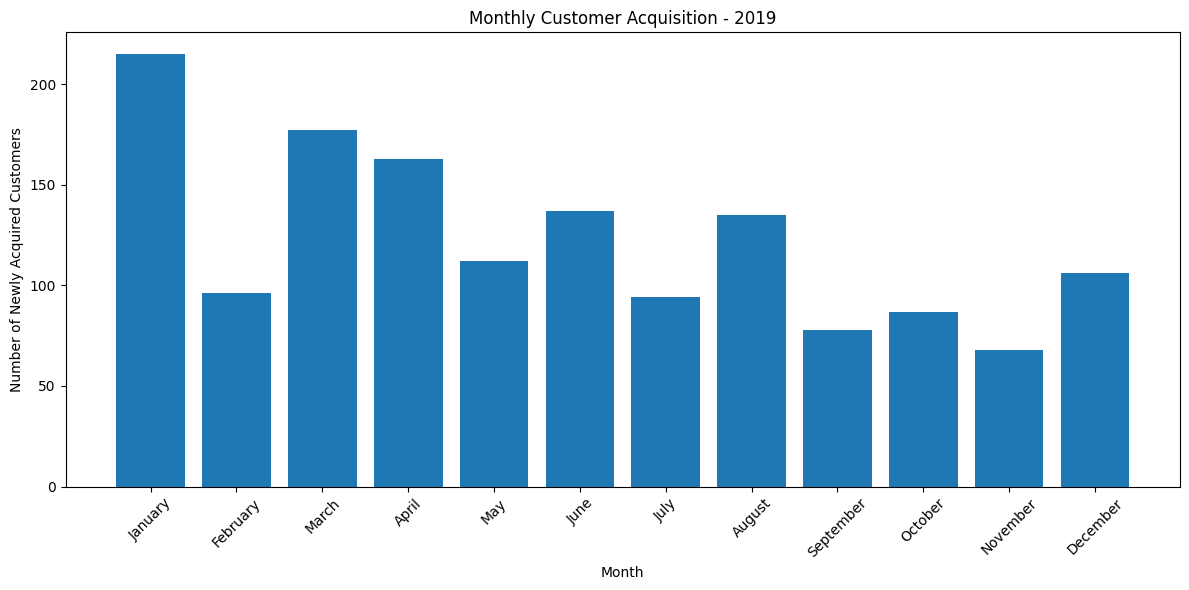

In [ ]:


# --------------------------------------------
# 6. Calculate Monthly Customer Acquisition
# --------------------------------------------

monthly_acquisition = (
    customer_first_purchase
    .groupby("Acquisition_Month")
    .size()
    .reset_index(name="Customer_Acquisition_Count")
)


# --------------------------------------------
# 7. Add Month Names
# --------------------------------------------

month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

monthly_acquisition["Month"] = (
    monthly_acquisition["Acquisition_Month"].map(month_names)
)

monthly_acquisition = monthly_acquisition[
    ["Acquisition_Month", "Month", "Customer_Acquisition_Count"]
]


# --------------------------------------------
# 8. Display Monthly Acquisition
# --------------------------------------------

print("\nMonthly Customer Acquisition:")
print(monthly_acquisition)


# --------------------------------------------
# 9. Find Highest and Lowest Months
# --------------------------------------------

highest_month = monthly_acquisition.loc[
    monthly_acquisition["Customer_Acquisition_Count"].idxmax()
]

lowest_month = monthly_acquisition.loc[
    monthly_acquisition["Customer_Acquisition_Count"].idxmin()
]


print("\n------------------------------")
print("CUSTOMER ACQUISITION RESULTS")
print("------------------------------")

print(
    f"Highest Acquisition Month: {highest_month['Month']} "
    f"({highest_month['Customer_Acquisition_Count']} customers)"
)

print(
    f"Lowest Acquisition Month: {lowest_month['Month']} "
    f"({lowest_month['Customer_Acquisition_Count']} customers)"
)


# --------------------------------------------
# 10. Visualization
# --------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    monthly_acquisition["Month"],
    monthly_acquisition["Customer_Acquisition_Count"]
)

plt.title("Monthly Customer Acquisition - 2019")
plt.xlabel("Month")
plt.ylabel("Number of Newly Acquired Customers")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Consistent growth: Instead of relying heavily on seasonal peaks, maintain year-round acquisition through personalized promotions, controlled marketing investment, remarketing, referral programs, and monitoring monthly acquisition KPIs.

Instead of arbitrarily deciding what "high" and "low" mean, calculate the average.The ones above then average are marked as highand below  it as low

In [ ]:
average_acquisition = monthly_acquisition[
    "Customer_Acquisition_Count"
].mean()

print("Average Monthly Customer Acquisition:", round(average_acquisition, 2))
monthly_acquisition["Performance"] = np.where(
    monthly_acquisition["Customer_Acquisition_Count"] >= average_acquisition,
    "High Performing",
    "Low Performing"
)

monthly_acquisition

Average Monthly Customer Acquisition: 122.33


,Acquisition_Month,Month,Customer_Acquisition_Count,Performance
0,1,January,215,High Performing
1,2,February,96,Low Performing
2,3,March,177,High Performing
3,4,April,163,High Performing
4,5,May,112,Low Performing
5,6,June,137,High Performing
6,7,July,94,Low Performing
7,8,August,135,High Performing
8,9,September,78,Low Performing
9,10,October,87,Low Performing


Step 3: Identify high-performing months

In [ ]:
high_performing_months = monthly_acquisition[
    monthly_acquisition["Customer_Acquisition_Count"] >= average_acquisition
].sort_values(
    "Customer_Acquisition_Count",
    ascending=False
)

print("High Performing Months:")
print(
    high_performing_months[
        ["Month", "Customer_Acquisition_Count"]
    ]
)

High Performing Months:
     Month  Customer_Acquisition_Count
0  January                         215
2    March                         177
3    April                         163
5     June                         137
7   August                         135


Step 5: Visualize monthly acquisition

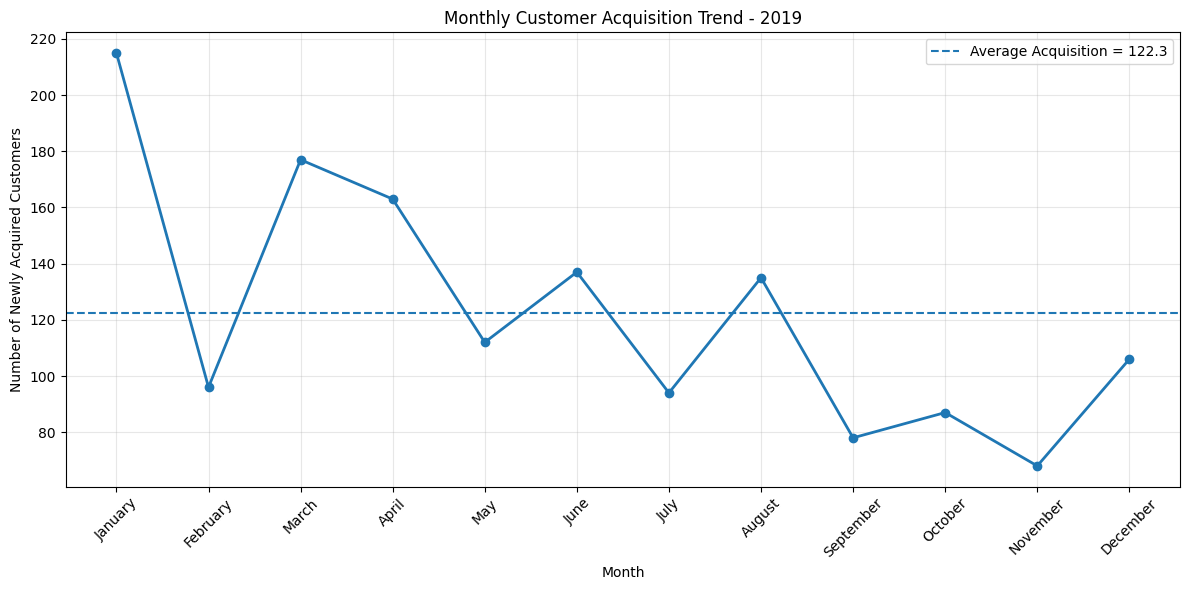

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_acquisition["Month"],
    monthly_acquisition["Customer_Acquisition_Count"],
    marker="o",
    linewidth=2
)

plt.axhline(
    y=average_acquisition,
    linestyle="--",
    label=f"Average Acquisition = {average_acquisition:.1f}"
)

plt.title("Monthly Customer Acquisition Trend - 2019")
plt.xlabel("Month")
plt.ylabel("Number of Newly Acquired Customers")

plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Step 6:interpretation

The monthly customer acquisition analysis shows noticeable variation in the number of newly acquired customers throughout 2019. Months with acquisition counts above the overall monthly average were classified as high-performing months, while months below the average were considered relatively low-performing.

The high-performing months indicate periods when customer demand, marketing activities, seasonal factors, promotions, or product-related factors may have contributed positively to customer acquisition. The company should further investigate marketing spend, coupon campaigns, product categories, and seasonal events during these months to identify the key drivers of strong acquisition.

To capitalize on high-performing months, the company can increase marketing investment around proven campaigns, ensure sufficient inventory for popular products, strengthen referral programs, and use successful promotional strategies across similar periods.

For slower months, the company can introduce targeted new-customer discounts, category-specific coupons, referral incentives, personalized digital campaigns, and remarketing initiatives. Marketing expenditure can also be shifted toward campaigns and channels that demonstrate stronger acquisition efficiency.




Monthly Retention:
      Month Next_Month  Total_Customers  Retained_Customers  Retention_Rate_%
0   2019-01    2019-02              215                  13          6.046512
1   2019-02    2019-03              109                  11         10.091743
2   2019-03    2019-04              208                  24         11.538462
3   2019-04    2019-05              224                  25         11.160714
4   2019-05    2019-06              200                  37         18.500000
5   2019-06    2019-07              259                  58         22.393822
6   2019-07    2019-08              236                  65         27.542373
7   2019-08    2019-09              300                  44         14.666667
8   2019-09    2019-10              193                  29         15.025907
9   2019-10    2019-11              210                  31         14.761905
10  2019-11    2019-12              188                  28         14.893617

------------------------------
RETENTION AN

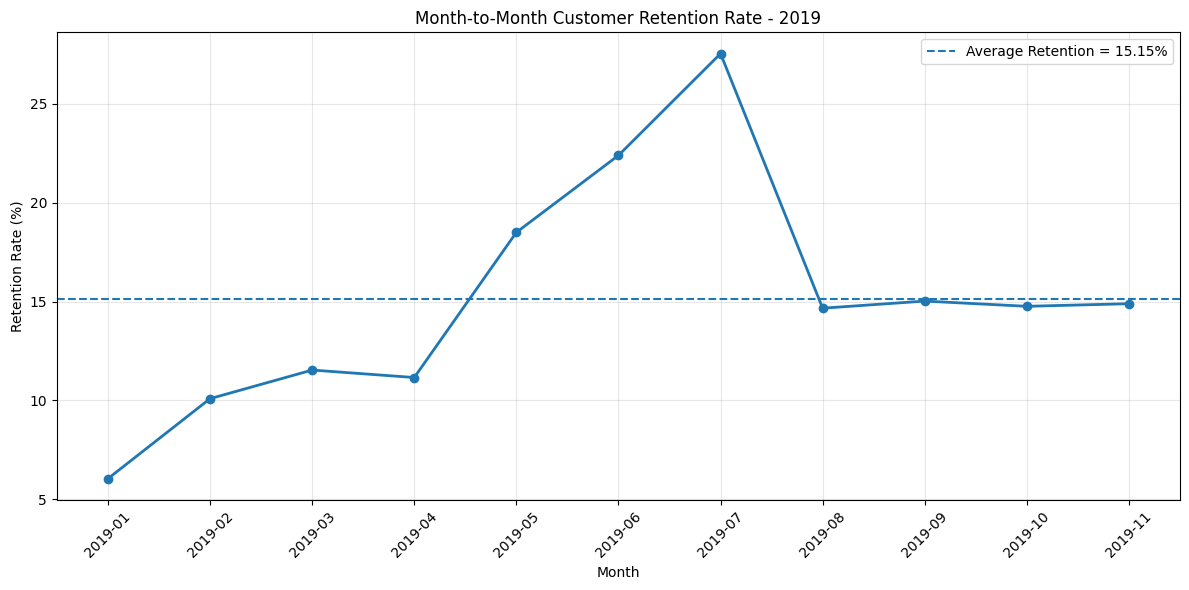

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------
# 1. Prepare Data
# ---------------------------------------------

online_sales["Transaction_Date"] = pd.to_datetime(
    online_sales["Transaction_Date"],
    errors="coerce"
)

retention_data = online_sales.dropna(
    subset=["CustomerID", "Transaction_Date"]
).copy()


# ---------------------------------------------
# 2. Extract Transaction Month
# ---------------------------------------------

retention_data["Transaction_Month"] = (
    retention_data["Transaction_Date"]
    .dt.to_period("M")
)


# ---------------------------------------------
# 3. Get Unique Customers Per Month
# ---------------------------------------------

monthly_customers = (
    retention_data[
        ["CustomerID", "Transaction_Month"]
    ]
    .drop_duplicates()
)


# ---------------------------------------------
# 4. Get Sorted Months
# ---------------------------------------------

months = sorted(
    monthly_customers["Transaction_Month"].unique()
)


# ---------------------------------------------
# 5. Calculate Month-to-Month Retention
# ---------------------------------------------

retention_results = []

for i in range(len(months) - 1):

    current_month = months[i]
    next_month = months[i + 1]

    current_customers = set(
        monthly_customers.loc[
            monthly_customers["Transaction_Month"] == current_month,
            "CustomerID"
        ]
    )

    next_customers = set(
        monthly_customers.loc[
            monthly_customers["Transaction_Month"] == next_month,
            "CustomerID"
        ]
    )

    retained_customers = (
        current_customers.intersection(next_customers)
    )

    total_customers = len(current_customers)

    retained_count = len(retained_customers)

    retention_rate = (
        retained_count / total_customers * 100
        if total_customers > 0
        else 0
    )

    retention_results.append({
        "Month": str(current_month),
        "Next_Month": str(next_month),
        "Total_Customers": total_customers,
        "Retained_Customers": retained_count,
        "Retention_Rate_%": retention_rate
    })


# ---------------------------------------------
# 6. Create Retention DataFrame
# ---------------------------------------------

retention_df = pd.DataFrame(retention_results)

print("\nMonthly Retention:")
print(retention_df)


# ---------------------------------------------
# 7. Average Retention
# ---------------------------------------------

average_retention = (
    retention_df["Retention_Rate_%"].mean()
)

retention_df["Retention_Performance"] = np.where(
    retention_df["Retention_Rate_%"] >= average_retention,
    "Above Average",
    "Below Average"
)


# ---------------------------------------------
# 8. Strongest & Weakest Retention
# ---------------------------------------------

strongest_retention = retention_df.loc[
    retention_df["Retention_Rate_%"].idxmax()
]

weakest_retention = retention_df.loc[
    retention_df["Retention_Rate_%"].idxmin()
]


print("\n------------------------------")
print("RETENTION ANALYSIS")
print("------------------------------")

print(
    f"Average Retention Rate: "
    f"{average_retention:.2f}%"
)

print(
    f"\nStrongest Retention Period: "
    f"{strongest_retention['Month']} → "
    f"{strongest_retention['Next_Month']}"
)

print(
    f"Retention Rate: "
    f"{strongest_retention['Retention_Rate_%']:.2f}%"
)

print(
    f"\nWeakest Retention Period: "
    f"{weakest_retention['Month']} → "
    f"{weakest_retention['Next_Month']}"
)

print(
    f"Retention Rate: "
    f"{weakest_retention['Retention_Rate_%']:.2f}%"
)


# ---------------------------------------------
# 9. Visualization
# ---------------------------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    retention_df["Month"],
    retention_df["Retention_Rate_%"],
    marker="o",
    linewidth=2
)

plt.axhline(
    y=average_retention,
    linestyle="--",
    label=f"Average Retention = {average_retention:.2f}%"
)

plt.title("Month-to-Month Customer Retention Rate - 2019")
plt.xlabel("Month")
plt.ylabel("Retention Rate (%)")

plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Customer retention was measured by identifying customers active in a given month who returned and made another purchase in the immediately following month. The monthly retention rate was calculated as the number of returning customers divided by the total number of customers active in the original month.

The analysis identifies the period with the highest retention rate as the strongest retention period and the period with the lowest retention rate as the weakest. A high retention rate indicates stronger repeat-purchase behavior and customer loyalty, whereas a low retention rate suggests a greater risk of customer churn.

During weaker retention periods, the company should focus on re-engagement strategies such as personalized follow-up offers, loyalty rewards, targeted coupons, product recommendations, and remarketing campaigns. Customers making their first purchase could also receive a time-bound incentive for completing a second purchase in the following month.

The company should further investigate customer behavior during high-retention periods, including product categories purchased, coupon usage, transaction value, and promotional activity. Strategies associated with stronger repeat-purchase behavior can then be replicated during weaker months.

Retention should be monitored alongside customer acquisition. High acquisition accompanied by poor subsequent retention may indicate that promotional campaigns are attracting customers who do not become repeat buyers. Therefore, the company should balance acquisition campaigns with loyalty and customer engagement initiatives to achieve sustainable growth.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

online_sales = pd.read_csv("Online_Sales.csv")
discount_coupon = pd.read_csv("Discount_Coupon.csv")
marketing_spend = pd.read_csv("Marketing_Spend.csv")

customers_data = pd.read_excel("CustomersData.xlsx")
tax_amount = pd.read_excel("Tax_amount.xlsx")

print("Online Sales Columns:")
print(online_sales.columns.tolist())

print("\nDiscount Coupon Columns:")
print(discount_coupon.columns.tolist())

print("\nMarketing Spend Columns:")
print(marketing_spend.columns.tolist())

print("\nCustomer Data Columns:")
print(customers_data.columns.tolist())

print("\nTax Amount Columns:")
print(tax_amount.columns.tolist())

Online Sales Columns:
['CustomerID', 'Transaction_ID', 'Transaction_Date', 'Product_SKU', 'Product_Description', 'Product_Category', 'Quantity', 'Avg_Price', 'Delivery_Charges', 'Coupon_Status']

Discount Coupon Columns:
['Month', 'Product_Category', 'Coupon_Code', 'Discount_pct']

Marketing Spend Columns:
['Date', 'Offline_Spend', 'Online_Spend']

Customer Data Columns:
['CustomerID', 'Gender', 'Location', 'Tenure_Months']

Tax Amount Columns:
['Product_Category', 'GST']


clean and rename the coloumns

In [ ]:
for df in [online_sales, discount_coupon, tax_amount]:
    df.columns = df.columns.str.strip()
    online_sales["Transaction_Date"] = pd.to_datetime(
    online_sales["Transaction_Date"],
    errors="coerce"
)

online_sales["Month"] = online_sales[
    "Transaction_Date"
].dt.month_name()
online_sales = online_sales.rename(
    columns={"Product_Cateogry": "Product_Category"}
)
online_sales["Product_Category"] = (
    online_sales["Product_Category"]
    .astype(str)
    .str.strip()
)

discount_coupon["Product_Category"] = (
    discount_coupon["Product_Category"]
    .astype(str)
    .str.strip()
)

tax_amount["Product_Category"] = (
    tax_amount["Product_Category"]
    .astype(str)
    .str.strip()
)

merging coloumn

In [ ]:
sales = online_sales.merge(
    discount_coupon[
        [
            "Month",
            "Product_Category",
            "Coupon_Code",
            "Discount_pct"
        ]
    ],
    on=["Month", "Product_Category"],
    how="left"
)
sales = sales.merge(
    tax_amount[
        ["Product_Category", "GST"]
    ],
    on="Product_Category",
    how="left"
)

Step 5 — Apply discount only when coupon was used

This is important.

Having a discount percentage in Discount_Coupon.csv doesn't necessarily mean every transaction received that discount.

We use Coupon_Status to determine whether the coupon was actually applied.

First inspect:

In [ ]:
print(
    sales["Coupon_Status"]
    .value_counts(dropna=False)
)
sales["Coupon_Used"] = (
    sales["Coupon_Status"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("used")
)

Coupon_Status
Clicked     26926
Used        17904
Not Used     8094
Name: count, dtype: int64


In [ ]:
print(sales["Discount_pct"].describe())
print(sales["GST"].describe())

count    4516.0
mean       20.0
std         0.0
min        20.0
25%        20.0
50%        20.0
75%        20.0
max        20.0
Name: Discount_pct, dtype: float64
count    52924.000000
mean         0.137462
std          0.045825
min          0.050000
25%          0.100000
50%          0.180000
75%          0.180000
max          0.180000
Name: GST, dtype: float64


In [ ]:
sales["Discount_pct"] = pd.to_numeric(
    sales["Discount_pct"],
    errors="coerce"
).fillna(0)

sales["GST"] = pd.to_numeric(
    sales["GST"],
    errors="coerce"
).fillna(0)

if sales["Discount_pct"].max() > 1:
    sales["Discount_pct"] = sales["Discount_pct"] / 100

if sales["GST"].max() > 1:
    sales["GST"] = sales["GST"] / 100

sales["Effective_Discount"] = np.where(
    sales["Coupon_Used"],
    sales["Discount_pct"],
    0
)

In [ ]:
sales["Revenue"] = (
    (
        sales["Quantity"] *
        sales["Avg_Price"]
    )
    *
    (1 - sales["Effective_Discount"])
    *
    (1 + sales["GST"])
    +
    sales["Delivery_Charges"]
)

In [ ]:
sales[
    [
        "CustomerID",
        "Transaction_ID",
        "Product_Category",
        "Quantity",
        "Avg_Price",
        "Effective_Discount",
        "GST",
        "Delivery_Charges",
        "Revenue"
    ]
].head()

,CustomerID,Transaction_ID,Product_Category,Quantity,Avg_Price,Effective_Discount,GST,Delivery_Charges,Revenue
0,17850,16679,Nest-USA,1,153.71,0.0,0.10,6.5,175.581
1,17850,16680,Nest-USA,1,153.71,0.0,0.10,6.5,175.581
2,17850,16681,Office,1,2.05,0.0,0.10,6.5,8.755
3,17850,16682,Apparel,5,17.53,0.0,0.18,6.5,109.927
4,17850,16682,Bags,1,16.50,0.0,0.18,6.5,25.970


q4

In [ ]:
Step 1 — Identify high-retention months

In [ ]:
high_retention = retention_df[
    retention_df["Retention_Rate_%"] >= average_retention
].copy()

print("High Retention Periods:")
print(
    high_retention[
        [
            "Month",
            "Next_Month",
            "Retention_Rate_%"
        ]
    ]
)

High Retention Periods:
     Month Next_Month  Retention_Rate_%
4  2019-05    2019-06         18.500000
5  2019-06    2019-07         22.393822
6  2019-07    2019-08         27.542373


Step 2 — Create year-month in sales

In [ ]:
sales["Year_Month"] = (
    sales["Transaction_Date"]
    .dt.to_period("M")
    .astype(str)
)
high_retention_months = high_retention[
    "Month"
].tolist()

print(high_retention_months)

['2019-05', '2019-06', '2019-07']


Step 3 — Extract transactions during those months

In [ ]:
high_retention_sales = sales[
    sales["Year_Month"].isin(high_retention_months)
].copy()
high_retention_sales.head()

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month,Coupon_Code,Discount_pct,GST,Coupon_Used,Effective_Discount,Revenue,Year_Month
15843,15514,26840,2019-05-01,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,3,79.00,12.99,Used,May,ELEC20,0.2,0.10,True,0.2,221.55000,2019-05
15844,15514,26842,2019-05-01,GGOEGAEB084513,BLM Sweatshirt,Apparel,1,33.59,6.00,Clicked,May,SALE20,0.2,0.18,False,0.0,45.63620,2019-05
15845,15514,26842,2019-05-01,GGOEGAEB084514,BLM Sweatshirt,Apparel,2,33.59,6.00,Used,May,SALE20,0.2,0.18,True,0.2,69.41792,2019-05
15846,15514,26843,2019-05-01,GGOEGAEB084516,BLM Sweatshirt,Apparel,1,33.59,6.00,Clicked,May,SALE20,0.2,0.18,False,0.0,45.63620,2019-05
15847,15514,26844,2019-05-01,GGOEGAEB084515,BLM Sweatshirt,Apparel,1,33.59,6.00,Used,May,SALE20,0.2,0.18,True,0.2,37.70896,2019-05


Step 4 — Analyze revenue

In [ ]:
high_retention_revenue = (
    high_retention_sales
    .groupby("Year_Month")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Average_Revenue=("Revenue", "mean"),
        Customers=("CustomerID", "nunique"),
        Transactions=("Transaction_ID", "nunique")
    )
    .reset_index()
)

high_retention_revenue

,Year_Month,Total_Revenue,Average_Revenue,Customers,Transactions
0,2019-05,365596.02956,79.964136,200,2034
1,2019-06,397002.93390,94.682312,259,1940
2,2019-07,465289.01890,88.609602,236,2080


Step 5 — Analyze product categories

In [ ]:
category_behavior = (
    high_retention_sales
    .groupby("Product_Category")
    .agg(
        Quantity_Sold=("Quantity", "sum"),
        Revenue=("Revenue", "sum"),
        Customers=("CustomerID", "nunique")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
    .reset_index()
)

category_behavior.head(10)

,Product_Category,Quantity_Sold,Revenue,Customers
0,Nest-USA,4882,645794.69000,449
1,Apparel,9687,244531.45464,501
2,Office,22728,97278.50120,397
3,Drinkware,8164,62900.54020,306
4,Bags,3858,45301.84604,237
5,Notebooks & Journals,3194,38807.13420,151
6,Lifestyle,7171,34027.62640,277
7,Nest-Canada,137,23517.14000,59
8,Headgear,434,8713.02210,154
9,Google,230,5113.72000,32


Step 6 — Analyze coupon usage

In [ ]:
coupon_behavior = (
    high_retention_sales
    .groupby("Coupon_Used")
    .agg(
        Transactions=("Transaction_ID", "nunique"),
        Revenue=("Revenue", "sum"),
        Average_Revenue=("Revenue", "mean")
    )
    .reset_index()
)

coupon_behavior

,Coupon_Used,Transactions,Revenue,Average_Revenue
0,False,4783,844061.02230,90.293220
1,True,3109,383826.96006,82.225141


Step 7 — Average quantity purchased

In [ ]:
high_retention_sales.groupby(
    "Year_Month"
)["Quantity"].mean()

,Quantity
Year_Month,
2019-05,4.093395
2019-06,5.155974
2019-07,4.360693


The analysis of high-retention months indicates the purchasing characteristics associated with stronger repeat-customer behavior. These periods can be evaluated using average transaction revenue, purchase quantity, coupon usage, transaction frequency, and product-category performance.

Product categories generating high revenue and attracting large numbers of customers during high-retention months should be prioritized in future retention campaigns. Similarly, if coupon usage is associated with stronger transaction activity without significantly reducing transaction value, targeted discounts may have contributed to repeat purchasing.

The company can replicate these conditions throughout the year by promoting high-engagement product categories, providing personalized recommendations based on previous purchases, introducing loyalty rewards, and offering time-bound incentives for subsequent purchases. Customers can also be targeted shortly after their first transaction with relevant cross-selling and repeat-purchase offers.

However, the company should avoid assuming that coupons alone cause higher retention. Other factors such as seasonality, product demand, customer mix, and marketing activities may also explain the observed behavior. The characteristics of high-retention months should therefore be used to design and test targeted retention campaigns during weaker periods.


Coupon Status Values:
Coupon_Status
Clicked     26926
Used        17904
Not Used     8094
Name: count, dtype: int64

Monthly Revenue by Customer Type:
   Transaction_Month      Customer_Type       Revenue
0            2019-01       New Customer  508514.75510
1            2019-02  Existing Customer   49784.68560
2            2019-02       New Customer  347080.97140
3            2019-03  Existing Customer   74933.23940
4            2019-03       New Customer  378271.82790
5            2019-04  Existing Customer  201853.32260
6            2019-04       New Customer  290706.38430
7            2019-05  Existing Customer  132338.74688
8            2019-05       New Customer  233257.28268
9            2019-06  Existing Customer  160076.14910
10           2019-06       New Customer  236926.78480
11           2019-07  Existing Customer  279620.57080
12           2019-07       New Customer  185668.44810
13           2019-08  Existing Customer  263821.96240
14           2019-08       New Customer

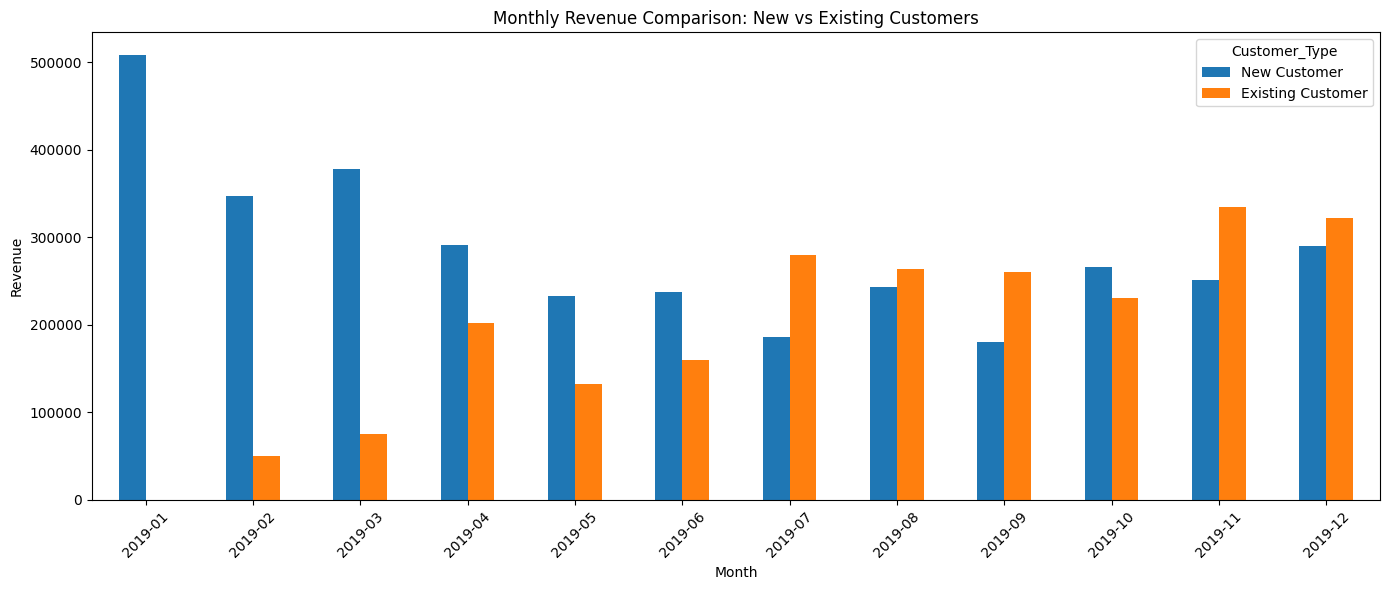

In [ ]:
# ============================================================
#
# Compare Revenue Generated by New vs Existing Customers
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

online_sales = pd.read_csv("Online_Sales.csv")
discount_coupon = pd.read_csv("Discount_Coupon.csv")
tax_amount = pd.read_excel("Tax_amount.xlsx")


# ------------------------------------------------------------
# 2. CLEAN COLUMN NAMES
# ------------------------------------------------------------

online_sales.columns = online_sales.columns.str.strip()
discount_coupon.columns = discount_coupon.columns.str.strip()
tax_amount.columns = tax_amount.columns.str.strip()


# ------------------------------------------------------------
# 3. STANDARDIZE PRODUCT CATEGORY COLUMN
# ------------------------------------------------------------

if "Product_Cateogry" in online_sales.columns:
    online_sales.rename(
        columns={"Product_Cateogry": "Product_Category"},
        inplace=True
    )


# ------------------------------------------------------------
# 4. CONVERT TRANSACTION DATE
# ------------------------------------------------------------

online_sales["Transaction_Date"] = pd.to_datetime(
    online_sales["Transaction_Date"],
    errors="coerce"
)

online_sales = online_sales.dropna(
    subset=["CustomerID", "Transaction_Date"]
).copy()


# ------------------------------------------------------------
# 5. CREATE MONTH COLUMNS
# ------------------------------------------------------------

online_sales["Month"] = (
    online_sales["Transaction_Date"].dt.month_name()
)

online_sales["Transaction_Month"] = (
    online_sales["Transaction_Date"].dt.to_period("M")
)


# ------------------------------------------------------------
# 6. CLEAN CATEGORY VALUES
# ------------------------------------------------------------

online_sales["Product_Category"] = (
    online_sales["Product_Category"]
    .astype(str)
    .str.strip()
)

discount_coupon["Product_Category"] = (
    discount_coupon["Product_Category"]
    .astype(str)
    .str.strip()
)

tax_amount["Product_Category"] = (
    tax_amount["Product_Category"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# 7. MERGE DISCOUNT DATA
# ------------------------------------------------------------

sales = online_sales.merge(
    discount_coupon[
        [
            "Month",
            "Product_Category",
            "Discount_pct"
        ]
    ],
    on=["Month", "Product_Category"],
    how="left"
)


# ------------------------------------------------------------
# 8. MERGE GST DATA
# ------------------------------------------------------------

sales = sales.merge(
    tax_amount[
        [
            "Product_Category",
            "GST"
        ]
    ],
    on="Product_Category",
    how="left"
)


# ------------------------------------------------------------
# 9. CONVERT DISCOUNT AND GST TO NUMERIC
# ------------------------------------------------------------

sales["Discount_pct"] = pd.to_numeric(
    sales["Discount_pct"],
    errors="coerce"
).fillna(0)

sales["GST"] = pd.to_numeric(
    sales["GST"],
    errors="coerce"
).fillna(0)


# Convert percentage values such as 10 to 0.10
if sales["Discount_pct"].max() > 1:
    sales["Discount_pct"] = sales["Discount_pct"] / 100

if sales["GST"].max() > 1:
    sales["GST"] = sales["GST"] / 100


# ------------------------------------------------------------
# 10. IDENTIFY WHETHER COUPON WAS USED
# ------------------------------------------------------------

print("Coupon Status Values:")
print(sales["Coupon_Status"].value_counts(dropna=False))

sales["Coupon_Used"] = (
    sales["Coupon_Status"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["used", "yes", "applied"])
)


# ------------------------------------------------------------
# 11. APPLY DISCOUNT ONLY WHEN COUPON IS USED
# ------------------------------------------------------------

sales["Effective_Discount"] = np.where(
    sales["Coupon_Used"],
    sales["Discount_pct"],
    0
)


# ------------------------------------------------------------
# 12. CALCULATE REVENUE / INVOICE VALUE
# ------------------------------------------------------------

sales["Revenue"] = (
    (
        sales["Quantity"] *
        sales["Avg_Price"]
    )
    *
    (1 - sales["Effective_Discount"])
    *
    (1 + sales["GST"])
    +
    sales["Delivery_Charges"]
)


# ------------------------------------------------------------
# 13. FIND FIRST PURCHASE MONTH FOR EACH CUSTOMER
# ------------------------------------------------------------

first_purchase = (
    sales
    .groupby("CustomerID")["Transaction_Date"]
    .min()
    .reset_index()
)

first_purchase["First_Purchase_Month"] = (
    first_purchase["Transaction_Date"].dt.to_period("M")
)

first_purchase.drop(
    columns=["Transaction_Date"],
    inplace=True
)


# ------------------------------------------------------------
# 14. MERGE FIRST PURCHASE MONTH
# ------------------------------------------------------------

sales = sales.merge(
    first_purchase,
    on="CustomerID",
    how="left"
)


# ------------------------------------------------------------
# 15. CLASSIFY CUSTOMER AS NEW OR EXISTING
# ------------------------------------------------------------

sales["Customer_Type"] = np.where(
    sales["Transaction_Month"] ==
    sales["First_Purchase_Month"],
    "New Customer",
    "Existing Customer"
)


# ------------------------------------------------------------
# 16. MONTHLY REVENUE BY CUSTOMER TYPE
# ------------------------------------------------------------

monthly_revenue = (
    sales
    .groupby(
        ["Transaction_Month", "Customer_Type"]
    )["Revenue"]
    .sum()
    .reset_index()
)

print("\nMonthly Revenue by Customer Type:")
print(monthly_revenue)


# ------------------------------------------------------------
# 17. CREATE PIVOT TABLE
# ------------------------------------------------------------

revenue_pivot = (
    monthly_revenue
    .pivot(
        index="Transaction_Month",
        columns="Customer_Type",
        values="Revenue"
    )
    .fillna(0)
)


# ------------------------------------------------------------
# 18. CALCULATE TOTAL AND REVENUE CONTRIBUTION %
# ------------------------------------------------------------

revenue_pivot["Total_Revenue"] = (
    revenue_pivot.sum(axis=1)
)

if "New Customer" in revenue_pivot.columns:

    revenue_pivot["New_Revenue_%"] = (
        revenue_pivot["New Customer"]
        / revenue_pivot["Total_Revenue"]
        * 100
    )


if "Existing Customer" in revenue_pivot.columns:

    revenue_pivot["Existing_Revenue_%"] = (
        revenue_pivot["Existing Customer"]
        / revenue_pivot["Total_Revenue"]
        * 100
    )


print("\nRevenue Comparison Table:")
print(revenue_pivot.round(2))


# ------------------------------------------------------------
# 19. OVERALL REVENUE CONTRIBUTION
# ------------------------------------------------------------

overall_revenue = (
    sales
    .groupby("Customer_Type")["Revenue"]
    .sum()
)

overall_percentage = (
    overall_revenue
    / overall_revenue.sum()
    * 100
)

print("\nOverall Revenue:")
print(overall_revenue.round(2))

print("\nOverall Revenue Percentage:")
print(overall_percentage.round(2))


# ------------------------------------------------------------
# 20. VISUALIZATION
# ------------------------------------------------------------

plot_columns = [
    col for col in
    ["New Customer", "Existing Customer"]
    if col in revenue_pivot.columns
]

revenue_pivot[plot_columns].plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title(
    "Monthly Revenue Comparison: New vs Existing Customers"
)

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The month-over-month revenue analysis separates customers into new customers, whose first purchase occurred during the respective month, and existing customers, who had previously purchased from the company.

Comparing the revenue contribution of these groups provides insight into whether business growth is primarily acquisition-driven or retention-driven. Months where new-customer revenue contributes a large proportion of total revenue indicate strong acquisition performance. In contrast, months where existing customers generate a larger share of revenue demonstrate the importance of repeat purchases and customer loyalty.

A sustainable business should maintain a balance between the two groups. Excessive dependence on new-customer revenue may indicate weak retention and require continuous spending on customer acquisition. Conversely, very high dependence on existing customers without sufficient new acquisition may restrict future customer-base growth.

The company should therefore continue investing in campaigns that attract high-quality new customers while simultaneously improving onboarding, loyalty programs, personalized recommendations, and repeat-purchase incentives to convert newly acquired customers into long-term existing customers.


Coupon Status Values:
Coupon_Status
Clicked     26926
Used        17904
Not Used     8094
Name: count, dtype: int64

Coupon Revenue Summary:
   Coupon_Used  Transactions  Customers  Total_Quantity  Average_Quantity  \
0        False         19455       1440          155242              4.43   
1         True         12258       1374           82791              4.62   

   Total_Revenue  Average_Line_Revenue  Revenue_Share_%  
0     3823051.94                109.17            66.83  
1     1897733.61                105.99            33.17  

Transaction-Level Comparison:
   Coupon_Used  Number_of_Transactions  Average_Transaction_Value  \
0        False                   12803                     197.39   
1         True                   12258                     260.54   

   Median_Transaction_Value  Total_Transaction_Revenue  \
0                    143.89                 2527123.42   
1                    153.07                 3193662.13   

   Average_Items_Per_Transaction  
0   

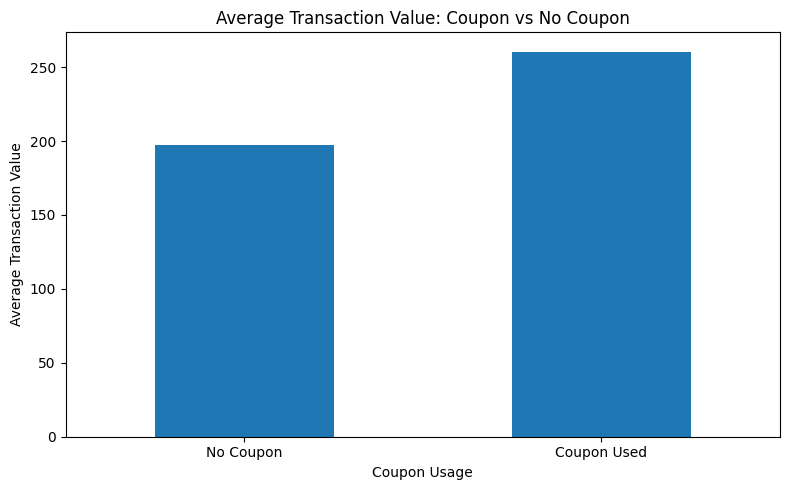

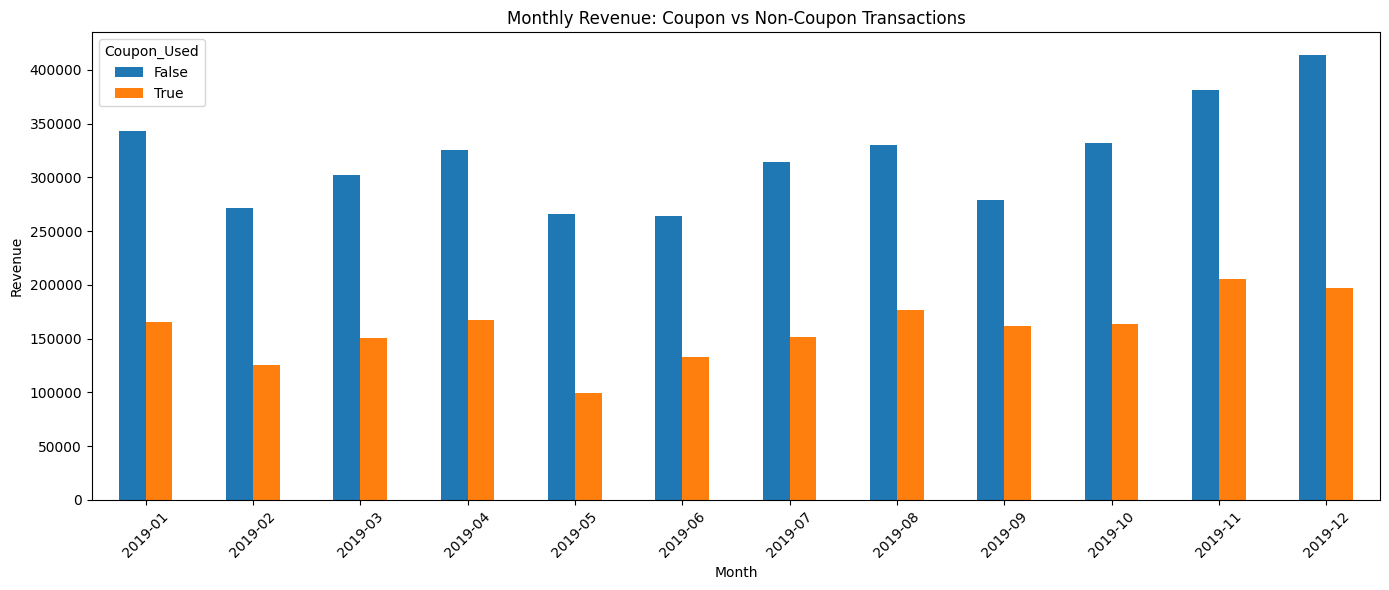

In [ ]:
# ============================================================
# Coupon Usage vs Revenue Analysis
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

online_sales = pd.read_csv("Online_Sales.csv")
discount_coupon = pd.read_csv("Discount_Coupon.csv")
tax_amount = pd.read_excel("Tax_amount.xlsx")


# ------------------------------------------------------------
# 2. CLEAN COLUMN NAMES
# ------------------------------------------------------------

online_sales.columns = online_sales.columns.str.strip()
discount_coupon.columns = discount_coupon.columns.str.strip()
tax_amount.columns = tax_amount.columns.str.strip()


# ------------------------------------------------------------
# 3. STANDARDIZE PRODUCT CATEGORY COLUMN
# ------------------------------------------------------------

if "Product_Cateogry" in online_sales.columns:
    online_sales.rename(
        columns={"Product_Cateogry": "Product_Category"},
        inplace=True
    )


# ------------------------------------------------------------
# 4. CONVERT TRANSACTION DATE
# ------------------------------------------------------------

online_sales["Transaction_Date"] = pd.to_datetime(
    online_sales["Transaction_Date"],
    errors="coerce"
)

online_sales = online_sales.dropna(
    subset=["CustomerID", "Transaction_Date"]
).copy()


# ------------------------------------------------------------
# 5. CREATE MONTH COLUMNS
# ------------------------------------------------------------

online_sales["Month"] = (
    online_sales["Transaction_Date"].dt.month_name()
)

online_sales["Transaction_Month"] = (
    online_sales["Transaction_Date"].dt.to_period("M")
)


# ------------------------------------------------------------
# 6. CLEAN PRODUCT CATEGORY VALUES
# ------------------------------------------------------------

online_sales["Product_Category"] = (
    online_sales["Product_Category"]
    .astype(str)
    .str.strip()
)

discount_coupon["Product_Category"] = (
    discount_coupon["Product_Category"]
    .astype(str)
    .str.strip()
)

tax_amount["Product_Category"] = (
    tax_amount["Product_Category"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# 7. MERGE DISCOUNT DATA
# ------------------------------------------------------------

sales = online_sales.merge(
    discount_coupon[
        [
            "Month",
            "Product_Category",
            "Discount_pct"
        ]
    ],
    on=["Month", "Product_Category"],
    how="left"
)


# ------------------------------------------------------------
# 8. MERGE GST DATA
# ------------------------------------------------------------

sales = sales.merge(
    tax_amount[
        [
            "Product_Category",
            "GST"
        ]
    ],
    on="Product_Category",
    how="left"
)


# ------------------------------------------------------------
# 9. CONVERT DISCOUNT AND GST TO NUMERIC
# ------------------------------------------------------------

sales["Discount_pct"] = pd.to_numeric(
    sales["Discount_pct"],
    errors="coerce"
).fillna(0)

sales["GST"] = pd.to_numeric(
    sales["GST"],
    errors="coerce"
).fillna(0)


if sales["Discount_pct"].max() > 1:
    sales["Discount_pct"] = (
        sales["Discount_pct"] / 100
    )

if sales["GST"].max() > 1:
    sales["GST"] = (
        sales["GST"] / 100
    )


# ------------------------------------------------------------
# 10. CHECK COUPON STATUS VALUES
# ------------------------------------------------------------

print("Coupon Status Values:")
print(
    sales["Coupon_Status"]
    .value_counts(dropna=False)
)


# ------------------------------------------------------------
# 11. IDENTIFY COUPON USAGE
# ------------------------------------------------------------

sales["Coupon_Used"] = (
    sales["Coupon_Status"]
    .astype(str)
    .str.strip()
    .str.lower()
    .isin(["used", "yes", "applied"])
)


# ------------------------------------------------------------
# 12. APPLY DISCOUNT ONLY WHEN COUPON WAS USED
# ------------------------------------------------------------

sales["Effective_Discount"] = np.where(
    sales["Coupon_Used"],
    sales["Discount_pct"],
    0
)


# ------------------------------------------------------------
# 13. CALCULATE REVENUE
# ------------------------------------------------------------

sales["Revenue"] = (
    (
        sales["Quantity"] *
        sales["Avg_Price"]
    )
    *
    (1 - sales["Effective_Discount"])
    *
    (1 + sales["GST"])
    +
    sales["Delivery_Charges"]
)


# ------------------------------------------------------------
# 14. COUPON VS NON-COUPON SUMMARY
# ------------------------------------------------------------

coupon_summary = (
    sales
    .groupby("Coupon_Used")
    .agg(
        Transactions=("Transaction_ID", "nunique"),
        Customers=("CustomerID", "nunique"),
        Total_Quantity=("Quantity", "sum"),
        Average_Quantity=("Quantity", "mean"),
        Total_Revenue=("Revenue", "sum"),
        Average_Line_Revenue=("Revenue", "mean")
    )
    .reset_index()
)


# ------------------------------------------------------------
# 15. CALCULATE REVENUE SHARE
# ------------------------------------------------------------

coupon_summary["Revenue_Share_%"] = (
    coupon_summary["Total_Revenue"]
    / coupon_summary["Total_Revenue"].sum()
    * 100
)

print("\nCoupon Revenue Summary:")
print(coupon_summary.round(2))


# ------------------------------------------------------------
# 16. CREATE TRANSACTION-LEVEL DATA
# ------------------------------------------------------------

transaction_level = (
    sales
    .groupby("Transaction_ID")
    .agg(
        CustomerID=("CustomerID", "first"),
        Coupon_Used=("Coupon_Used", "max"),
        Transaction_Value=("Revenue", "sum"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)


# ------------------------------------------------------------
# 17. AVERAGE TRANSACTION VALUE
# ------------------------------------------------------------

transaction_comparison = (
    transaction_level
    .groupby("Coupon_Used")
    .agg(
        Number_of_Transactions=(
            "Transaction_ID",
            "count"
        ),
        Average_Transaction_Value=(
            "Transaction_Value",
            "mean"
        ),
        Median_Transaction_Value=(
            "Transaction_Value",
            "median"
        ),
        Total_Transaction_Revenue=(
            "Transaction_Value",
            "sum"
        ),
        Average_Items_Per_Transaction=(
            "Quantity",
            "mean"
        )
    )
    .reset_index()
)

print("\nTransaction-Level Comparison:")
print(transaction_comparison.round(2))


# ------------------------------------------------------------
# 18. MONTHLY COUPON REVENUE
# ------------------------------------------------------------

monthly_coupon_revenue = (
    sales
    .groupby(
        ["Transaction_Month", "Coupon_Used"]
    )["Revenue"]
    .sum()
    .reset_index()
)

monthly_coupon_pivot = (
    monthly_coupon_revenue
    .pivot(
        index="Transaction_Month",
        columns="Coupon_Used",
        values="Revenue"
    )
    .fillna(0)
)

print("\nMonthly Coupon Revenue:")
print(monthly_coupon_pivot.round(2))


# ------------------------------------------------------------
# 19. VISUALIZATION 1
# Average Transaction Value
# ------------------------------------------------------------

avg_transaction_value = (
    transaction_level
    .groupby("Coupon_Used")[
        "Transaction_Value"
    ]
    .mean()
)

avg_transaction_value.index = [
    "No Coupon" if x is False
    else "Coupon Used"
    for x in avg_transaction_value.index
]

avg_transaction_value.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Average Transaction Value: Coupon vs No Coupon"
)

plt.xlabel("Coupon Usage")
plt.ylabel("Average Transaction Value")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 20. VISUALIZATION 2
# Monthly Coupon vs Non-Coupon Revenue
# ------------------------------------------------------------

monthly_coupon_pivot.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title(
    "Monthly Revenue: Coupon vs Non-Coupon Transactions"
)

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The relationship between coupon usage and revenue can be evaluated by comparing total revenue, revenue share, average transaction value, purchase quantity, and customer participation between coupon and non-coupon transactions.

Higher total revenue from coupon transactions does not necessarily mean that discounts are more profitable, since coupons directly reduce the selling price and therefore may reduce margins. Their effectiveness should instead be evaluated by determining whether the discount generates sufficient incremental customer activity, larger basket sizes, or repeat purchases to compensate for the reduced price.

If coupon users demonstrate higher average transaction values or purchase quantities, coupons may be successfully encouraging customers to increase their basket size. Conversely, if coupon transactions have substantially lower transaction values without a corresponding increase in quantity, customer acquisition, or retention, the company may be offering unnecessary discounts.

The company should therefore move from broad discounting toward targeted coupon strategies. Coupons can be directed toward first-time customers to encourage second purchases, customers at risk of churn, slower sales periods, and product categories where additional demand can be generated profitably.

Minimum-spend thresholds can also be introduced so that customers must reach a specified basket value before receiving a discount. Category-specific and personalized coupons may further improve efficiency by offering incentives where they are most likely to influence purchasing behavior.

Ultimately, coupon performance should be evaluated using both revenue and profitability. Since the provided datasets contain revenue-related variables but do not appear to include product cost or gross margin, the analysis can measure revenue effectiveness but cannot determine the true profit generated by coupon campaigns.



RFM SEGMENT SUMMARY
    Segment  Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  \
0      Gold        312       142.15          18.44       3800.82   
1   Premium        408        63.41          40.27       8449.65   
2    Silver        341       154.27           8.84       1572.91   
3  Standard        407       222.27           3.53        559.42   

   Total_Revenue  
0     1185855.93  
1     3447457.58  
2      536363.17  
3      227682.06  


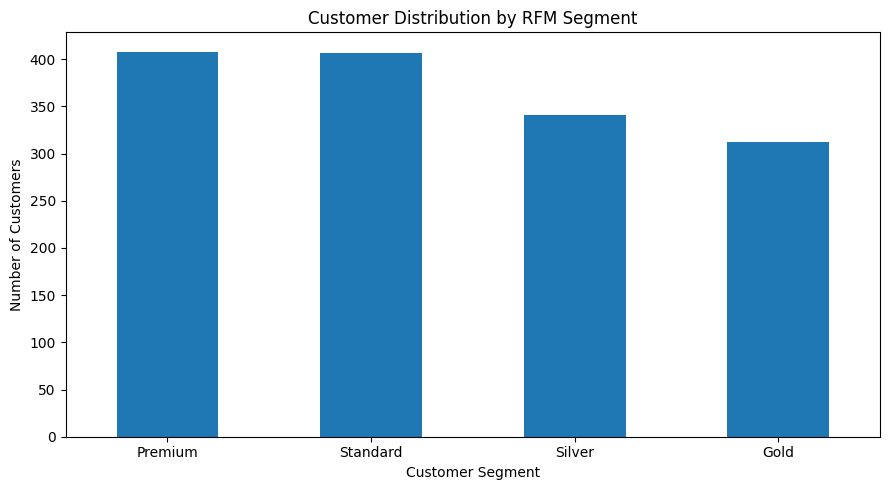

In [ ]:
# ============================================================
# - RFM CUSTOMER SEGMENTATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar


# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

online_sales = pd.read_csv("Online_Sales.csv")
discount_coupon = pd.read_csv("Discount_Coupon.csv")
tax_amount = pd.read_excel("Tax_amount.xlsx")


# ------------------------------------------------------------
# 2. CLEAN COLUMN NAMES
# ------------------------------------------------------------

for df in [online_sales, discount_coupon, tax_amount]:
    df.columns = df.columns.str.strip()


if "Product_Cateogry" in online_sales.columns:
    online_sales.rename(
        columns={"Product_Cateogry": "Product_Category"},
        inplace=True
    )


# ------------------------------------------------------------
# 3. DATE PREPARATION
# ------------------------------------------------------------

online_sales["Transaction_Date"] = pd.to_datetime(
    online_sales["Transaction_Date"],
    errors="coerce"
)

online_sales = online_sales.dropna(
    subset=["CustomerID", "Transaction_Date"]
).copy()

online_sales["Month_Num"] = online_sales["Transaction_Date"].dt.month


# ------------------------------------------------------------
# 4. NORMALIZE MONTH IN COUPON DATA
# ------------------------------------------------------------

month_map = {
    name[:3].lower(): i
    for i, name in enumerate(calendar.month_name)
    if name
}

discount_coupon["Month_Num"] = (
    discount_coupon["Month"]
    .astype(str)
    .str.strip()
    .str[:3]
    .str.lower()
    .map(month_map)
)


# ------------------------------------------------------------
# 5. CLEAN CATEGORY
# ------------------------------------------------------------

for df in [online_sales, discount_coupon, tax_amount]:
    df["Product_Category"] = (
        df["Product_Category"]
        .astype(str)
        .str.strip()
    )


# ------------------------------------------------------------
# 6. MERGE DISCOUNT
# ------------------------------------------------------------

sales = online_sales.merge(
    discount_coupon[
        ["Month_Num", "Product_Category", "Discount_pct"]
    ],
    on=["Month_Num", "Product_Category"],
    how="left"
)


# ------------------------------------------------------------
# 7. MERGE GST
# ------------------------------------------------------------

sales = sales.merge(
    tax_amount[
        ["Product_Category", "GST"]
    ],
    on="Product_Category",
    how="left"
)


# ------------------------------------------------------------
# 8. CLEAN PERCENTAGES
# ------------------------------------------------------------

sales["Discount_pct"] = pd.to_numeric(
    sales["Discount_pct"],
    errors="coerce"
).fillna(0)

sales["GST"] = pd.to_numeric(
    sales["GST"],
    errors="coerce"
).fillna(0)

if sales["Discount_pct"].max() > 1:
    sales["Discount_pct"] /= 100

if sales["GST"].max() > 1:
    sales["GST"] /= 100


# ------------------------------------------------------------
# 9. COUPON USED
# ------------------------------------------------------------

sales["Coupon_Used"] = (
    sales["Coupon_Status"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("used")
)

sales["Effective_Discount"] = np.where(
    sales["Coupon_Used"],
    sales["Discount_pct"],
    0
)


# ------------------------------------------------------------
# 10. CALCULATE REVENUE
# ------------------------------------------------------------

sales["Revenue"] = (
    (sales["Quantity"] * sales["Avg_Price"])
    * (1 - sales["Effective_Discount"])
    * (1 + sales["GST"])
    + sales["Delivery_Charges"]
)


# ------------------------------------------------------------
# 11. RFM CALCULATION
# ------------------------------------------------------------

reference_date = sales["Transaction_Date"].max() + pd.Timedelta(days=1)

rfm = (
    sales.groupby("CustomerID")
    .agg(
        Recency=(
            "Transaction_Date",
            lambda x: (reference_date - x.max()).days
        ),
        Frequency=("Transaction_ID", "nunique"),
        Monetary=("Revenue", "sum")
    )
    .reset_index()
)


# ------------------------------------------------------------
# 12. CREATE RFM SCORES
# ------------------------------------------------------------

# Lower recency is better
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    4,
    labels=[4, 3, 2, 1]
).astype(int)

# Higher frequency is better
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

# Higher monetary value is better
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)


rfm["RFM_Total"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)


# ------------------------------------------------------------
# 13. CUSTOMER SEGMENTS
# ------------------------------------------------------------

def segment_customer(score):

    if score >= 10:
        return "Premium"

    elif score >= 8:
        return "Gold"

    elif score >= 6:
        return "Silver"

    else:
        return "Standard"


rfm["Segment"] = rfm["RFM_Total"].apply(segment_customer)


# ------------------------------------------------------------
# 14. SEGMENT SUMMARY
# ------------------------------------------------------------

segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "nunique"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
        Total_Revenue=("Monetary", "sum")
    )
    .reset_index()
)

print("\nRFM SEGMENT SUMMARY")
print(segment_summary.round(2))


# ------------------------------------------------------------
# 15. VISUALIZATION
# ------------------------------------------------------------

segment_counts = rfm["Segment"].value_counts()

segment_counts.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Business recommendations

Premium: VIP benefits, early access, exclusive products, personalized recommendations and loyalty rewards. Avoid excessive discounts because these customers already demonstrate strong spending and engagement.

Gold: Encourage progression to Premium through threshold-based rewards, cross-selling and loyalty milestones.

Silver: Increase purchase frequency using personalized category recommendations, limited-time promotions and bundle offers.

Standard: Re-engagement campaigns, first-repeat-purchase incentives and carefully targeted coupons can help reactivate these customers.


REVENUE CONTRIBUTION BY CUSTOMER SEGMENT
    Segment  Customers     Revenue  Average_Customer_Value  \
1   Premium        408  3447457.58                 8449.65   
0      Gold        312  1185855.93                 3800.82   
2    Silver        341   536363.17                 1572.91   
3  Standard        407   227682.06                  559.42   

   Revenue_Contribution_%  
1                   63.87  
0                   21.97  
2                    9.94  
3                    4.22  


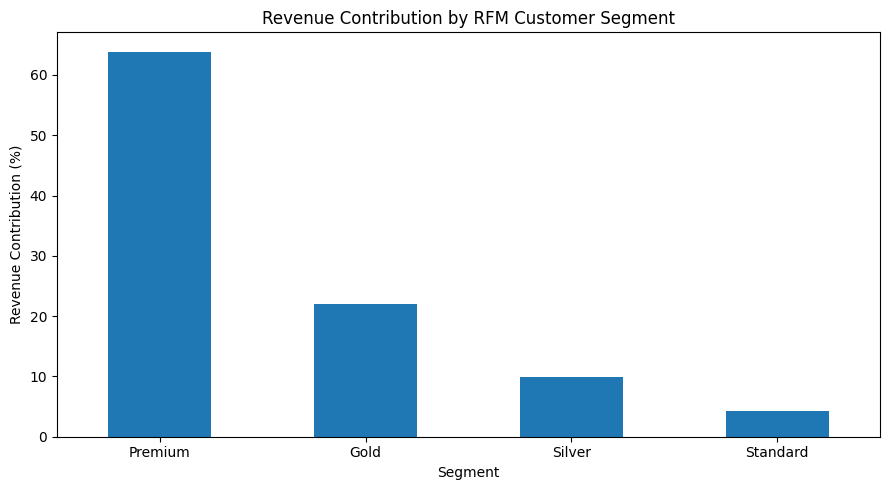

In [ ]:
# ====================================================== REVENUE CONTRIBUTION BY RFM SEGMENT
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar


# Load datasets
online_sales = pd.read_csv("Online_Sales.csv")
discount_coupon = pd.read_csv("Discount_Coupon.csv")
tax_amount = pd.read_excel("Tax_amount.xlsx")


for df in [online_sales, discount_coupon, tax_amount]:
    df.columns = df.columns.str.strip()


if "Product_Cateogry" in online_sales.columns:
    online_sales.rename(
        columns={"Product_Cateogry": "Product_Category"},
        inplace=True
    )


online_sales["Transaction_Date"] = pd.to_datetime(
    online_sales["Transaction_Date"],
    errors="coerce"
)

online_sales = online_sales.dropna(
    subset=["CustomerID", "Transaction_Date"]
)

online_sales["Month_Num"] = online_sales["Transaction_Date"].dt.month


month_map = {
    name[:3].lower(): i
    for i, name in enumerate(calendar.month_name)
    if name
}

discount_coupon["Month_Num"] = (
    discount_coupon["Month"]
    .astype(str)
    .str.strip()
    .str[:3]
    .str.lower()
    .map(month_map)
)


for df in [online_sales, discount_coupon, tax_amount]:
    df["Product_Category"] = (
        df["Product_Category"].astype(str).str.strip()
    )


sales = online_sales.merge(
    discount_coupon[
        ["Month_Num", "Product_Category", "Discount_pct"]
    ],
    on=["Month_Num", "Product_Category"],
    how="left"
)

sales = sales.merge(
    tax_amount[["Product_Category", "GST"]],
    on="Product_Category",
    how="left"
)


sales["Discount_pct"] = pd.to_numeric(
    sales["Discount_pct"],
    errors="coerce"
).fillna(0)

sales["GST"] = pd.to_numeric(
    sales["GST"],
    errors="coerce"
).fillna(0)


if sales["Discount_pct"].max() > 1:
    sales["Discount_pct"] /= 100

if sales["GST"].max() > 1:
    sales["GST"] /= 100


sales["Coupon_Used"] = (
    sales["Coupon_Status"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("used")
)

sales["Effective_Discount"] = np.where(
    sales["Coupon_Used"],
    sales["Discount_pct"],
    0
)


sales["Revenue"] = (
    (sales["Quantity"] * sales["Avg_Price"])
    * (1 - sales["Effective_Discount"])
    * (1 + sales["GST"])
    + sales["Delivery_Charges"]
)


reference_date = sales["Transaction_Date"].max() + pd.Timedelta(days=1)


rfm = (
    sales.groupby("CustomerID")
    .agg(
        Recency=(
            "Transaction_Date",
            lambda x: (reference_date - x.max()).days
        ),
        Frequency=("Transaction_ID", "nunique"),
        Monetary=("Revenue", "sum")
    )
    .reset_index()
)


rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    4,
    labels=[4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)


rfm["RFM_Total"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)


def segment(score):

    if score >= 10:
        return "Premium"
    elif score >= 8:
        return "Gold"
    elif score >= 6:
        return "Silver"
    return "Standard"


rfm["Segment"] = rfm["RFM_Total"].apply(segment)


# Revenue by segment
segment_revenue = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "nunique"),
        Revenue=("Monetary", "sum"),
        Average_Customer_Value=("Monetary", "mean")
    )
    .reset_index()
)


segment_revenue["Revenue_Contribution_%"] = (
    segment_revenue["Revenue"]
    / segment_revenue["Revenue"].sum()
    * 100
)


segment_revenue = segment_revenue.sort_values(
    "Revenue",
    ascending=False
)


print("\nREVENUE CONTRIBUTION BY CUSTOMER SEGMENT")
print(segment_revenue.round(2))


segment_revenue.set_index("Segment")[
    "Revenue_Contribution_%"
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Revenue Contribution by RFM Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Revenue Contribution (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Interpretation

Premium and Gold customers should receive the highest retention priority because losing a relatively small number of these customers could have a disproportionately large revenue impact.

However, Silver and Standard customers should not be ignored. Use lower-cost automated engagement, personalized recommendations and milestone incentives to gradually move them toward higher-value segments.


COHORT RETENTION MATRIX (%)
Cohort_Index     0      1      2      3      4      5      6      7      8   \
Cohort_Month                                                                  
2019-01       100.0   6.05  11.16  15.81  10.70  20.47  16.28  21.86  10.70   
2019-02       100.0   7.29   9.38  16.67  17.71  22.92  19.79  15.62  12.50   
2019-03       100.0  10.17  19.77  14.12  18.08  18.64  12.43  12.43   8.47   
2019-04       100.0   8.59  14.72  14.72  11.04   9.20   6.13   9.82   7.36   
2019-05       100.0  10.71   8.04  11.61   8.93  11.61  12.50   7.14    NaN   
2019-06       100.0  14.60  16.06   8.76   8.03  10.22   8.03    NaN    NaN   
2019-07       100.0  13.83   4.26   6.38  11.70   9.57    NaN    NaN    NaN   
2019-08       100.0  10.37  11.11   7.41   5.93    NaN    NaN    NaN    NaN   
2019-09       100.0   7.69   3.85   2.56    NaN    NaN    NaN    NaN    NaN   
2019-10       100.0   6.90   4.60    NaN    NaN    NaN    NaN    NaN    NaN   
2019-11       100.0  10

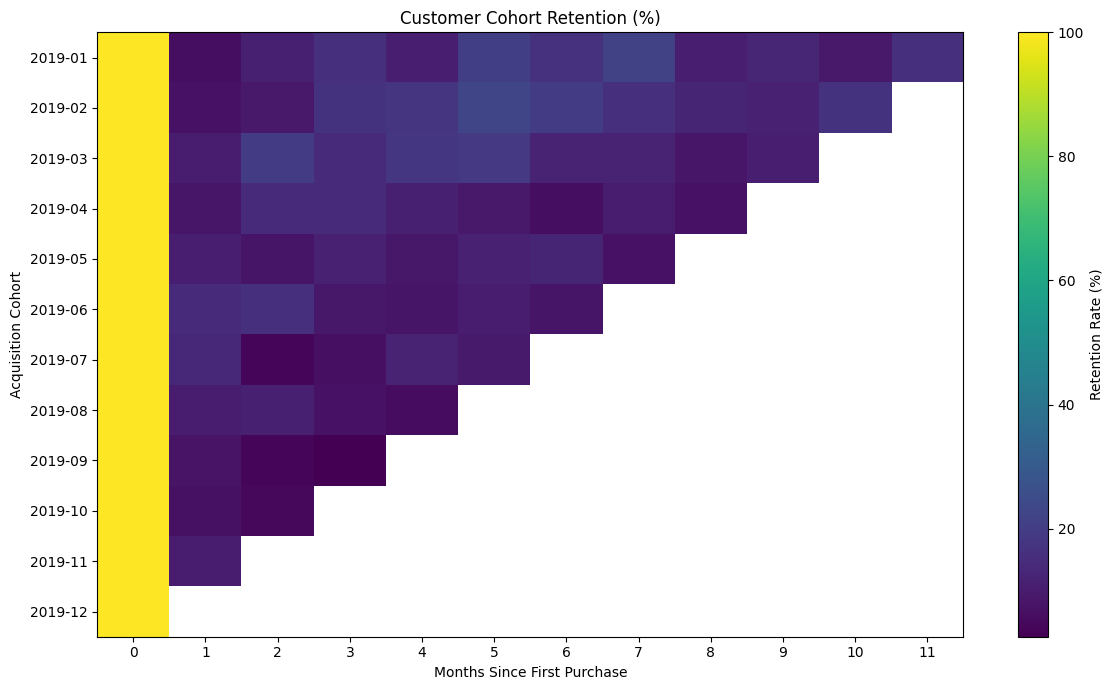

In [ ]:
# ============================================================
# COHORT RETENTION ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


online_sales = pd.read_csv("Online_Sales.csv")

online_sales.columns = online_sales.columns.str.strip()

online_sales["Transaction_Date"] = pd.to_datetime(
    online_sales["Transaction_Date"],
    errors="coerce"
)

online_sales = online_sales.dropna(
    subset=["CustomerID", "Transaction_Date"]
).copy()


# Transaction month
online_sales["Transaction_Month"] = (
    online_sales["Transaction_Date"].dt.to_period("M")
)


# First purchase month
online_sales["Cohort_Month"] = (
    online_sales.groupby("CustomerID")[
        "Transaction_Date"
    ].transform("min").dt.to_period("M")
)


# Calculate number of months since acquisition
online_sales["Cohort_Index"] = (
    (
        online_sales["Transaction_Month"].dt.year
        - online_sales["Cohort_Month"].dt.year
    ) * 12
    +
    (
        online_sales["Transaction_Month"].dt.month
        - online_sales["Cohort_Month"].dt.month
    )
)


# Unique customers per cohort and period
cohort_data = (
    online_sales.groupby(
        ["Cohort_Month", "Cohort_Index"]
    )["CustomerID"]
    .nunique()
    .reset_index(name="Customers")
)


# Cohort size
cohort_size = (
    cohort_data[
        cohort_data["Cohort_Index"] == 0
    ][["Cohort_Month", "Customers"]]
    .rename(columns={"Customers": "Cohort_Size"})
)


cohort_data = cohort_data.merge(
    cohort_size,
    on="Cohort_Month"
)


cohort_data["Retention_Rate"] = (
    cohort_data["Customers"]
    / cohort_data["Cohort_Size"]
    * 100
)


retention_matrix = cohort_data.pivot(
    index="Cohort_Month",
    columns="Cohort_Index",
    values="Retention_Rate"
)


print("\nCOHORT RETENTION MATRIX (%)")
print(retention_matrix.round(2))


# Compare Month-1 retention
month1_retention = (
    cohort_data[
        cohort_data["Cohort_Index"] == 1
    ]
    .sort_values(
        "Retention_Rate",
        ascending=False
    )
)


print("\nMONTH-1 RETENTION BY COHORT")
print(
    month1_retention[
        ["Cohort_Month", "Retention_Rate"]
    ].round(2)
)


if len(month1_retention) > 0:

    strongest = month1_retention.iloc[0]
    weakest = month1_retention.iloc[-1]

    print(
        "\nStrongest Cohort:",
        strongest["Cohort_Month"],
        f"({strongest['Retention_Rate']:.2f}%)"
    )

    print(
        "Weakest Cohort:",
        weakest["Cohort_Month"],
        f"({weakest['Retention_Rate']:.2f}%)"
    )


# Heatmap using matplotlib
fig, ax = plt.subplots(figsize=(12, 7))

matrix = retention_matrix.values

im = ax.imshow(
    matrix,
    aspect="auto"
)

ax.set_xticks(range(len(retention_matrix.columns)))
ax.set_xticklabels(retention_matrix.columns)

ax.set_yticks(range(len(retention_matrix.index)))
ax.set_yticklabels(
    retention_matrix.index.astype(str)
)

ax.set_xlabel("Months Since First Purchase")
ax.set_ylabel("Acquisition Cohort")
ax.set_title("Customer Cohort Retention (%)")

plt.colorbar(
    im,
    ax=ax,
    label="Retention Rate (%)"
)

plt.tight_layout()
plt.show()

Business answer

Strong cohorts should be examined for the campaigns, categories and offers present during their acquisition period. Weak cohorts should receive stronger onboarding, second-purchase incentives, personalized recommendations and early lifecycle communication.

The first 30–60 days after acquisition are particularly important because improving the second-purchase rate can have a large downstream effect on retention.


CUSTOMER LIFETIME VALUE BY ACQUISITION MONTH
   Acquisition_Month  Customers  Total_Lifetime_Revenue  Average_Customer_LTV  \
0            2019-01        215              1227511.26               5709.35   
1            2019-02         96               636073.09               6625.76   
2            2019-03        177               769307.02               4346.37   
3            2019-04        163               523464.52               3211.44   
4            2019-05        112               386306.89               3449.17   
5            2019-06        137               332681.57               2428.33   
6            2019-07         94               277810.47               2955.43   
7            2019-08        135               302180.10               2238.37   
8            2019-09         78               168107.79               2155.23   
9            2019-10         87               270950.23               3114.37   
10           2019-11         68               239550.88        

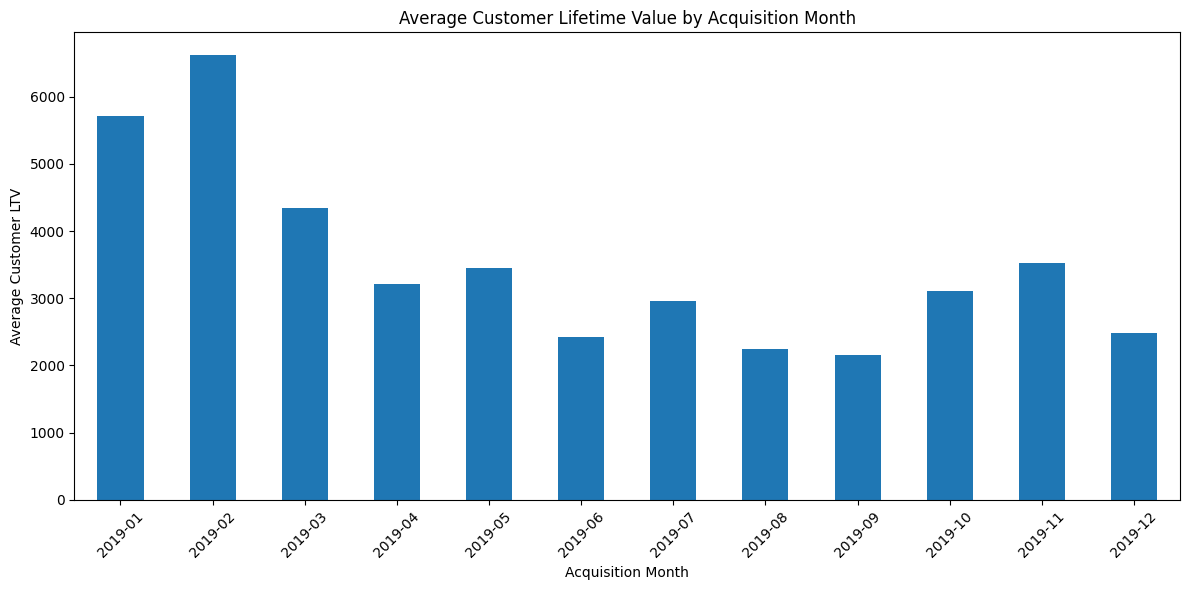

In [ ]:
# ============================================================
# CUSTOMER LIFETIME VALUE BY ACQUISITION MONTH
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import calendar


online_sales = pd.read_csv("Online_Sales.csv")
discount_coupon = pd.read_csv("Discount_Coupon.csv")
tax_amount = pd.read_excel("Tax_amount.xlsx")


for df in [online_sales, discount_coupon, tax_amount]:
    df.columns = df.columns.str.strip()


if "Product_Cateogry" in online_sales.columns:
    online_sales.rename(
        columns={"Product_Cateogry": "Product_Category"},
        inplace=True
    )


online_sales["Transaction_Date"] = pd.to_datetime(
    online_sales["Transaction_Date"],
    errors="coerce"
)

online_sales = online_sales.dropna(
    subset=["CustomerID", "Transaction_Date"]
)

online_sales["Month_Num"] = (
    online_sales["Transaction_Date"].dt.month
)


month_map = {
    name[:3].lower(): i
    for i, name in enumerate(calendar.month_name)
    if name
}

discount_coupon["Month_Num"] = (
    discount_coupon["Month"]
    .astype(str)
    .str.strip()
    .str[:3]
    .str.lower()
    .map(month_map)
)


for df in [online_sales, discount_coupon, tax_amount]:
    df["Product_Category"] = (
        df["Product_Category"].astype(str).str.strip()
    )


sales = online_sales.merge(
    discount_coupon[
        ["Month_Num", "Product_Category", "Discount_pct"]
    ],
    on=["Month_Num", "Product_Category"],
    how="left"
)

sales = sales.merge(
    tax_amount[["Product_Category", "GST"]],
    on="Product_Category",
    how="left"
)


sales["Discount_pct"] = pd.to_numeric(
    sales["Discount_pct"],
    errors="coerce"
).fillna(0)

sales["GST"] = pd.to_numeric(
    sales["GST"],
    errors="coerce"
).fillna(0)


if sales["Discount_pct"].max() > 1:
    sales["Discount_pct"] /= 100

if sales["GST"].max() > 1:
    sales["GST"] /= 100


sales["Coupon_Used"] = (
    sales["Coupon_Status"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("used")
)


sales["Effective_Discount"] = np.where(
    sales["Coupon_Used"],
    sales["Discount_pct"],
    0
)


sales["Revenue"] = (
    (sales["Quantity"] * sales["Avg_Price"])
    * (1 - sales["Effective_Discount"])
    * (1 + sales["GST"])
    + sales["Delivery_Charges"]
)


# First purchase month
first_purchase = (
    sales.groupby("CustomerID")[
        "Transaction_Date"
    ]
    .min()
    .reset_index(name="First_Purchase_Date")
)

first_purchase["Acquisition_Month"] = (
    first_purchase["First_Purchase_Date"]
    .dt.to_period("M")
)


# Customer lifetime revenue observed in 2019
customer_ltv = (
    sales.groupby("CustomerID")["Revenue"]
    .sum()
    .reset_index(name="Customer_Lifetime_Value")
)


customer_ltv = customer_ltv.merge(
    first_purchase[
        ["CustomerID", "Acquisition_Month"]
    ],
    on="CustomerID"
)


ltv_by_month = (
    customer_ltv.groupby("Acquisition_Month")
    .agg(
        Customers=("CustomerID", "nunique"),
        Total_Lifetime_Revenue=(
            "Customer_Lifetime_Value",
            "sum"
        ),
        Average_Customer_LTV=(
            "Customer_Lifetime_Value",
            "mean"
        ),
        Median_Customer_LTV=(
            "Customer_Lifetime_Value",
            "median"
        )
    )
    .reset_index()
)


print("\nCUSTOMER LIFETIME VALUE BY ACQUISITION MONTH")
print(ltv_by_month.round(2))


best = ltv_by_month.loc[
    ltv_by_month["Average_Customer_LTV"].idxmax()
]

lowest = ltv_by_month.loc[
    ltv_by_month["Average_Customer_LTV"].idxmin()
]


print(
    "\nHighest Average LTV Cohort:",
    best["Acquisition_Month"],
    round(best["Average_Customer_LTV"], 2)
)

print(
    "Lowest Average LTV Cohort:",
    lowest["Acquisition_Month"],
    round(lowest["Average_Customer_LTV"], 2)
)


ltv_by_month.plot(
    x="Acquisition_Month",
    y="Average_Customer_LTV",
    kind="bar",
    figsize=(12, 6),
    legend=False
)

plt.title("Average Customer Lifetime Value by Acquisition Month")
plt.xlabel("Acquisition Month")
plt.ylabel("Average Customer LTV")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Important interpretation

This is technically observed customer value during the available 2019 period, not true unlimited lifetime value.

January customers have almost twelve months to accumulate revenue, while December customers have only one month. Therefore, later cohorts naturally have less observation time.

Use high-value cohorts to determine which acquisition periods generate customers with stronger long-term economic value, not merely more customers.

Coupon Transactions: 12258
Non-Coupon Transactions: 12803

Average Coupon Transaction Value: 234.15
Average Non-Coupon Transaction Value: 197.39

T Statistic: 6.3703
P Value: 0.0

Result: Reject H0.
There is a statistically significant difference in average transaction value.


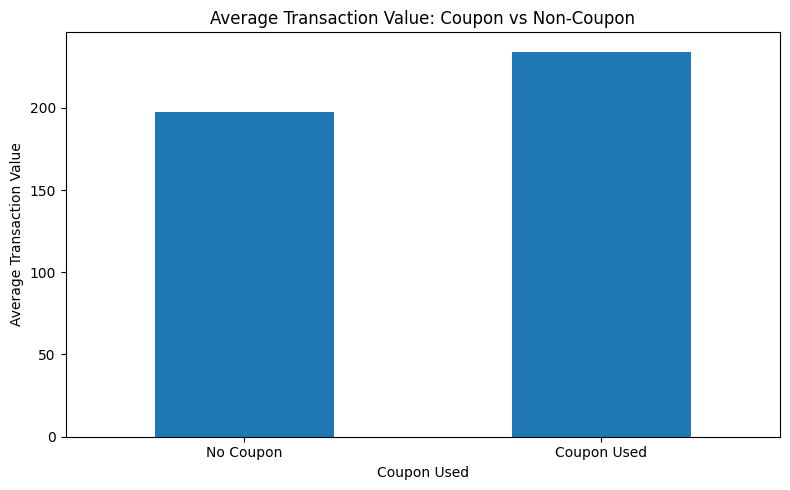

In [ ]:
# ============================================================
# STATISTICAL TEST - COUPON VS NON-COUPON TRANSACTION VALUE
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import calendar


online_sales = pd.read_csv("Online_Sales.csv")
discount_coupon = pd.read_csv("Discount_Coupon.csv")
tax_amount = pd.read_excel("Tax_amount.xlsx")


for df in [online_sales, discount_coupon, tax_amount]:
    df.columns = df.columns.str.strip()


if "Product_Cateogry" in online_sales.columns:
    online_sales.rename(
        columns={"Product_Cateogry": "Product_Category"},
        inplace=True
    )


online_sales["Transaction_Date"] = pd.to_datetime(
    online_sales["Transaction_Date"],
    errors="coerce"
)

online_sales["Month_Num"] = (
    online_sales["Transaction_Date"].dt.month
)


month_map = {
    name[:3].lower(): i
    for i, name in enumerate(calendar.month_name)
    if name
}

discount_coupon["Month_Num"] = (
    discount_coupon["Month"]
    .astype(str)
    .str.strip()
    .str[:3]
    .str.lower()
    .map(month_map)
)


for df in [online_sales, discount_coupon, tax_amount]:
    df["Product_Category"] = (
        df["Product_Category"].astype(str).str.strip()
    )


sales = online_sales.merge(
    discount_coupon[
        ["Month_Num", "Product_Category", "Discount_pct"]
    ],
    on=["Month_Num", "Product_Category"],
    how="left"
)

sales = sales.merge(
    tax_amount[["Product_Category", "GST"]],
    on="Product_Category",
    how="left"
)


sales["Discount_pct"] = pd.to_numeric(
    sales["Discount_pct"],
    errors="coerce"
).fillna(0)

sales["GST"] = pd.to_numeric(
    sales["GST"],
    errors="coerce"
).fillna(0)


if sales["Discount_pct"].max() > 1:
    sales["Discount_pct"] /= 100

if sales["GST"].max() > 1:
    sales["GST"] /= 100


sales["Coupon_Used"] = (
    sales["Coupon_Status"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("used")
)


sales["Effective_Discount"] = np.where(
    sales["Coupon_Used"],
    sales["Discount_pct"],
    0
)


sales["Revenue"] = (
    (sales["Quantity"] * sales["Avg_Price"])
    * (1 - sales["Effective_Discount"])
    * (1 + sales["GST"])
    + sales["Delivery_Charges"]
)


# Transaction level
transactions = (
    sales.groupby("Transaction_ID")
    .agg(
        Coupon_Used=("Coupon_Used", "max"),
        Transaction_Value=("Revenue", "sum")
    )
    .reset_index()
)


coupon_values = transactions.loc[
    transactions["Coupon_Used"],
    "Transaction_Value"
]

no_coupon_values = transactions.loc[
    ~transactions["Coupon_Used"],
    "Transaction_Value"
]


print("Coupon Transactions:", len(coupon_values))
print("Non-Coupon Transactions:", len(no_coupon_values))

print(
    "\nAverage Coupon Transaction Value:",
    round(coupon_values.mean(), 2)
)

print(
    "Average Non-Coupon Transaction Value:",
    round(no_coupon_values.mean(), 2)
)


# Welch t-test
t_stat, p_value = ttest_ind(
    coupon_values,
    no_coupon_values,
    equal_var=False,
    nan_policy="omit"
)


print("\nT Statistic:", round(t_stat, 4))
print("P Value:", round(p_value, 6))


alpha = 0.05

if p_value < alpha:

    print(
        "\nResult: Reject H0."
    )

    print(
        "There is a statistically significant difference "
        "in average transaction value."
    )

else:

    print(
        "\nResult: Fail to reject H0."
    )

    print(
        "There is insufficient evidence of a significant "
        "difference in average transaction value."
    )


transactions.groupby(
    "Coupon_Used"
)["Transaction_Value"].mean().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Transaction Value: Coupon vs Non-Coupon")
plt.xlabel("Coupon Used")
plt.ylabel("Average Transaction Value")
plt.xticks(
    [0, 1],
    ["No Coupon", "Coupon Used"],
    rotation=0
)
plt.tight_layout()
plt.show()

Business interpretation

If p < 0.05, the difference is statistically significant.

If coupon transactions also have a higher average transaction value, discounts may be encouraging larger baskets. If coupon transactions have significantly lower values, broad discounting may be eroding revenue per order.

Use minimum-spend coupons, targeted offers and category-specific promotions instead of indiscriminate discounting.


PURCHASE BEHAVIOR BY LOCATION
               Transactions  Avg_Order_Value  Avg_Quantity
Location                                                  
Chicago                8774           210.77         10.02
California             7574           211.76          9.63
New York               5256           202.26          8.71
New Jersey             2142           202.70          9.55
Washington DC          1315           210.65          8.33

PURCHASE BEHAVIOR BY GENDER
        Transactions  Avg_Order_Value  Avg_Quantity
Gender                                             
F              15633           209.12          9.90
M               9428           207.71          8.84

PURCHASE BEHAVIOR BY DELIVERY CHARGE TIER
               Transactions  Avg_Order_Value  Avg_Quantity
Delivery_Tier                                             
Low                   12720           177.38          6.30
Medium                 8725           196.92          6.23
High                   3616           34

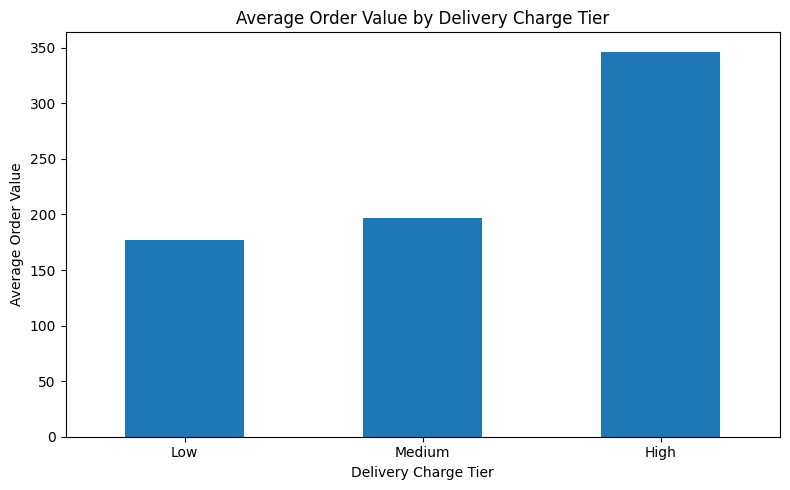

In [ ]:
# ============================================================
# PURCHASE BEHAVIOR ACROSS DEMOGRAPHIC / PRICING GROUPS
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import f_oneway, ttest_ind
import matplotlib.pyplot as plt


sales = pd.read_csv("Online_Sales.csv")
customers = pd.read_excel("CustomersData.xlsx")


sales.columns = sales.columns.str.strip()
customers.columns = customers.columns.str.strip()


sales["Transaction_Date"] = pd.to_datetime(
    sales["Transaction_Date"],
    errors="coerce"
)


# Basic order value before tax/discount for demographic comparison
sales["Order_Line_Value"] = (
    sales["Quantity"]
    * sales["Avg_Price"]
    + sales["Delivery_Charges"]
)


transaction_data = (
    sales.groupby("Transaction_ID")
    .agg(
        CustomerID=("CustomerID", "first"),
        Order_Value=("Order_Line_Value", "sum"),
        Quantity=("Quantity", "sum"),
        Delivery_Charges=("Delivery_Charges", "max")
    )
    .reset_index()
)


transaction_data = transaction_data.merge(
    customers,
    on="CustomerID",
    how="left"
)


# ------------------------------------------------------------
# DELIVERY CHARGE TIERS
# ------------------------------------------------------------

transaction_data["Delivery_Tier"] = pd.qcut(
    transaction_data["Delivery_Charges"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)


# ------------------------------------------------------------
# LOCATION SUMMARY
# ------------------------------------------------------------

location_summary = (
    transaction_data.groupby("Location")
    .agg(
        Transactions=("Transaction_ID", "nunique"),
        Avg_Order_Value=("Order_Value", "mean"),
        Avg_Quantity=("Quantity", "mean")
    )
    .sort_values(
        "Transactions",
        ascending=False
    )
)

print("\nPURCHASE BEHAVIOR BY LOCATION")
print(location_summary.round(2))


# ------------------------------------------------------------
# GENDER SUMMARY
# ------------------------------------------------------------

gender_summary = (
    transaction_data.groupby("Gender")
    .agg(
        Transactions=("Transaction_ID", "nunique"),
        Avg_Order_Value=("Order_Value", "mean"),
        Avg_Quantity=("Quantity", "mean")
    )
)

print("\nPURCHASE BEHAVIOR BY GENDER")
print(gender_summary.round(2))


# ------------------------------------------------------------
# DELIVERY TIER SUMMARY
# ------------------------------------------------------------

delivery_summary = (
    transaction_data.groupby(
        "Delivery_Tier",
        observed=False
    )
    .agg(
        Transactions=("Transaction_ID", "nunique"),
        Avg_Order_Value=("Order_Value", "mean"),
        Avg_Quantity=("Quantity", "mean")
    )
)

print("\nPURCHASE BEHAVIOR BY DELIVERY CHARGE TIER")
print(delivery_summary.round(2))


# ------------------------------------------------------------
# ANOVA BY LOCATION
# Use locations with sufficient observations
# ------------------------------------------------------------

valid_locations = (
    transaction_data["Location"]
    .value_counts()
)

valid_locations = valid_locations[
    valid_locations >= 20
].index


location_groups = [
    transaction_data.loc[
        transaction_data["Location"] == location,
        "Order_Value"
    ].dropna()
    for location in valid_locations
]


if len(location_groups) >= 2:

    f_stat, p_value = f_oneway(*location_groups)

    print("\nANOVA - ORDER VALUE ACROSS LOCATIONS")
    print("F Statistic:", round(f_stat, 4))
    print("P Value:", round(p_value, 6))


# ------------------------------------------------------------
# ANOVA BY DELIVERY TIER
# ------------------------------------------------------------

delivery_groups = [
    group["Order_Value"].dropna()
    for _, group in transaction_data.groupby(
        "Delivery_Tier",
        observed=False
    )
]


if len(delivery_groups) >= 2:

    f_delivery, p_delivery = f_oneway(
        *delivery_groups
    )

    print("\nANOVA - ORDER VALUE ACROSS DELIVERY TIERS")
    print("F Statistic:", round(f_delivery, 4))
    print("P Value:", round(p_delivery, 6))


# ------------------------------------------------------------
# GENDER TEST
# ------------------------------------------------------------

gender_names = transaction_data[
    "Gender"
].dropna().unique()


if len(gender_names) == 2:

    group1 = transaction_data.loc[
        transaction_data["Gender"] == gender_names[0],
        "Order_Value"
    ]

    group2 = transaction_data.loc[
        transaction_data["Gender"] == gender_names[1],
        "Order_Value"
    ]

    t_stat, p_gender = ttest_ind(
        group1,
        group2,
        equal_var=False,
        nan_policy="omit"
    )

    print("\nT-TEST - ORDER VALUE BY GENDER")
    print("P Value:", round(p_gender, 6))


# Visualization
delivery_summary["Avg_Order_Value"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Order Value by Delivery Charge Tier")
plt.xlabel("Delivery Charge Tier")
plt.ylabel("Average Order Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Interpretation

For each statistical test:

p < 0.05 → significant differences between groups.
p ≥ 0.05 → insufficient evidence of meaningful differences.

Use statistically meaningful location differences for localized promotions and pricing. Delivery-sensitive groups could receive free-shipping thresholds or lower delivery charges.

In [ ]:
# ============================================================
# CUSTOMER TENURE VS PURCHASE FREQUENCY
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import spearmanr, ttest_ind
import matplotlib.pyplot as plt


sales = pd.read_csv("Online_Sales.csv")
customers = pd.read_excel("CustomersData.xlsx")


sales.columns = sales.columns.str.strip()
customers.columns = customers.columns.str.strip()


# Purchase frequency
frequency = (
    sales.groupby("CustomerID")
    ["Transaction_ID"]
    .nunique()
    .reset_index(name="Purchase_Frequency")
)


customer_frequency = customers.merge(
    frequency,
    on="CustomerID",
    how="left"
)


customer_frequency["Purchase_Frequency"] = (
    customer_frequency["Purchase_Frequency"]
    .fillna(0)
)


customer_frequency["Tenure_Months"] = pd.to_numeric(
    customer_frequency["Tenure_Months"],
    errors="coerce"
)


customer_frequency = customer_frequency[
    customer_frequency["Tenure_Months"] > 0
].copy()


# Normalize purchase frequency
customer_frequency["Purchases_Per_Month"] = (
    customer_frequency["Purchase_Frequency"]
    / customer_frequency["Tenure_Months"]
)


print(customer_frequency[
    [
        "CustomerID",
        "Tenure_Months",
        "Purchase_Frequency",
        "Purchases_Per_Month"
    ]
].head())


# ------------------------------------------------------------
# SPEARMAN CORRELATION
# ------------------------------------------------------------

rho, p_value = spearmanr(
    customer_frequency["Tenure_Months"],
    customer_frequency["Purchase_Frequency"]
)


print("\nTENURE VS TOTAL PURCHASE FREQUENCY")
print("Spearman Correlation:", round(rho, 4))
print("P Value:", round(p_value, 6))


rho_norm, p_norm = spearmanr(
    customer_frequency["Tenure_Months"],
    customer_frequency["Purchases_Per_Month"]
)


print("\nTENURE VS PURCHASES PER MONTH")
print("Spearman Correlation:", round(rho_norm, 4))
print("P Value:", round(p_norm, 6))


# ------------------------------------------------------------
# LOW VS HIGH TENURE
# ------------------------------------------------------------

median_tenure = (
    customer_frequency["Tenure_Months"].median()
)


customer_frequency["Tenure_Group"] = np.where(
    customer_frequency["Tenure_Months"] <= median_tenure,
    "Low Tenure",
    "High Tenure"
)


summary = (
    customer_frequency.groupby("Tenure_Group")
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Frequency=("Purchase_Frequency", "mean"),
        Avg_Purchases_Per_Month=(
            "Purchases_Per_Month",
            "mean"
        )
    )
)

print("\nTENURE GROUP SUMMARY")
print(summary.round(3))


low = customer_frequency.loc[
    customer_frequency["Tenure_Group"] == "Low Tenure",
    "Purchases_Per_Month"
]

high = customer_frequency.loc[
    customer_frequency["Tenure_Group"] == "High Tenure",
    "Purchases_Per_Month"
]


t_stat, p_group = ttest_ind(
    low,
    high,
    equal_var=False,
    nan_policy="omit"
)


print("\nLOW VS HIGH TENURE T-TEST")
print("P Value:", round(p_group, 6))


plt.figure(figsize=(8, 5))

plt.scatter(
    customer_frequency["Tenure_Months"],
    customer_frequency["Purchase_Frequency"],
    alpha=0.4
)

plt.title("Customer Tenure vs Purchase Frequency")
plt.xlabel("Tenure (Months)")
plt.ylabel("Purchase Frequency")
plt.tight_layout()
plt.show()

Business recommendation

If longer-tenure customers purchase more frequently, loyalty programs and lifecycle engagement are likely valuable. If normalized purchases-per-month decline with tenure, older customers may be becoming less active, suggesting the need for reactivation campaigns.

In [ ]:
# ============================================================
# DELIVERY CHARGES VS ORDER BEHAVIOR
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import spearmanr, f_oneway
import matplotlib.pyplot as plt


sales = pd.read_csv("Online_Sales.csv")

sales.columns = sales.columns.str.strip()


sales["Basic_Revenue"] = (
    sales["Quantity"] * sales["Avg_Price"]
    + sales["Delivery_Charges"]
)


# Transaction-level analysis
orders = (
    sales.groupby("Transaction_ID")
    .agg(
        Quantity=("Quantity", "sum"),
        Revenue=("Basic_Revenue", "sum"),
        Delivery_Charges=("Delivery_Charges", "max")
    )
    .reset_index()
)


# Correlation
rho_quantity, p_quantity = spearmanr(
    orders["Delivery_Charges"],
    orders["Quantity"]
)

rho_revenue, p_revenue = spearmanr(
    orders["Delivery_Charges"],
    orders["Revenue"]
)


print("DELIVERY CHARGE VS QUANTITY")
print("Correlation:", round(rho_quantity, 4))
print("P Value:", round(p_quantity, 6))


print("\nDELIVERY CHARGE VS REVENUE")
print("Correlation:", round(rho_revenue, 4))
print("P Value:", round(p_revenue, 6))


# Delivery tiers
orders["Delivery_Tier"] = pd.qcut(
    orders["Delivery_Charges"],
    3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)


summary = (
    orders.groupby(
        "Delivery_Tier",
        observed=False
    )
    .agg(
        Orders=("Transaction_ID", "count"),
        Avg_Quantity=("Quantity", "mean"),
        Avg_Revenue=("Revenue", "mean")
    )
)


print("\nDELIVERY TIER SUMMARY")
print(summary.round(2))


groups = [
    group["Quantity"].dropna()
    for _, group in orders.groupby(
        "Delivery_Tier",
        observed=False
    )
]


if len(groups) >= 2:

    f_stat, p_anova = f_oneway(*groups)

    print("\nANOVA - ORDER QUANTITY BY DELIVERY TIER")
    print("P Value:", round(p_anova, 6))


summary["Avg_Quantity"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Order Quantity by Delivery Charge Tier")
plt.xlabel("Delivery Charge Tier")
plt.ylabel("Average Quantity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
Business interpretation

If higher delivery charges are associated with lower quantities, free-shipping thresholds or reduced delivery charges for larger baskets may increase orders.

If higher delivery charges occur mainly on already-large orders, be careful not to interpret correlation as causation.

In [ ]:
# ============================================================
# TAXES + DELIVERY CHARGES VS CUSTOMER SPENDING
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import spearmanr, f_oneway
import matplotlib.pyplot as plt


sales = pd.read_csv("Online_Sales.csv")
tax = pd.read_excel("Tax_amount.xlsx")


sales.columns = sales.columns.str.strip()
tax.columns = tax.columns.str.strip()


if "Product_Cateogry" in sales.columns:
    sales.rename(
        columns={"Product_Cateogry": "Product_Category"},
        inplace=True
    )


sales["Product_Category"] = (
    sales["Product_Category"].astype(str).str.strip()
)

tax["Product_Category"] = (
    tax["Product_Category"].astype(str).str.strip()
)


sales = sales.merge(
    tax,
    on="Product_Category",
    how="left"
)


sales["GST"] = pd.to_numeric(
    sales["GST"],
    errors="coerce"
).fillna(0)


if sales["GST"].max() > 1:
    sales["GST"] /= 100


sales["Pre_Tax_Value"] = (
    sales["Quantity"]
    * sales["Avg_Price"]
)


sales["Tax_Amount_Value"] = (
    sales["Pre_Tax_Value"]
    * sales["GST"]
)


sales["Spending_Value"] = (
    sales["Pre_Tax_Value"]
    + sales["Tax_Amount_Value"]
    + sales["Delivery_Charges"]
)


orders = (
    sales.groupby("Transaction_ID")
    .agg(
        Pre_Tax_Value=("Pre_Tax_Value", "sum"),
        Tax_Amount=("Tax_Amount_Value", "sum"),
        Delivery_Charges=("Delivery_Charges", "max"),
        Final_Spending=("Spending_Value", "sum"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)


# Correlation
tax_corr, tax_p = spearmanr(
    orders["Tax_Amount"],
    orders["Final_Spending"]
)

delivery_corr, delivery_p = spearmanr(
    orders["Delivery_Charges"],
    orders["Final_Spending"]
)


print("TAX VS FINAL SPENDING")
print("Correlation:", round(tax_corr, 4))
print("P Value:", round(tax_p, 6))


print("\nDELIVERY CHARGE VS FINAL SPENDING")
print("Correlation:", round(delivery_corr, 4))
print("P Value:", round(delivery_p, 6))


orders["Delivery_Tier"] = pd.qcut(
    orders["Delivery_Charges"],
    3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)


summary = (
    orders.groupby(
        "Delivery_Tier",
        observed=False
    )
    .agg(
        Orders=("Transaction_ID", "count"),
        Avg_Final_Spending=("Final_Spending", "mean"),
        Avg_Quantity=("Quantity", "mean")
    )
)


print("\nSPENDING BY DELIVERY TIER")
print(summary.round(2))


groups = [
    group["Final_Spending"].dropna()
    for _, group in orders.groupby(
        "Delivery_Tier",
        observed=False
    )
]


if len(groups) >= 2:

    f_stat, p_value = f_oneway(*groups)

    print("\nANOVA - SPENDING ACROSS DELIVERY TIERS")
    print("P Value:", round(p_value, 6))


summary["Avg_Final_Spending"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Customer Spending by Delivery Charge Tier")
plt.xlabel("Delivery Charge Tier")
plt.ylabel("Average Spending")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Interpretation

Tax will naturally have a positive mathematical relationship with invoice value because tax is part of the invoice calculation. Therefore, do not claim that higher tax causes customers to spend more.

The more useful business question is whether high taxes and delivery charges discourage quantity or transactions. Consider transparent pricing, shipping thresholds and targeted delivery discounts.

In [ ]:
# ============================================================
# SEASONAL SALES TRENDS BY CATEGORY AND LOCATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


sales = pd.read_csv("Online_Sales.csv")
customers = pd.read_excel("CustomersData.xlsx")


sales.columns = sales.columns.str.strip()
customers.columns = customers.columns.str.strip()


if "Product_Cateogry" in sales.columns:
    sales.rename(
        columns={"Product_Cateogry": "Product_Category"},
        inplace=True
    )


sales["Transaction_Date"] = pd.to_datetime(
    sales["Transaction_Date"],
    errors="coerce"
)


sales["Month_Num"] = sales[
    "Transaction_Date"
].dt.month

sales["Month"] = sales[
    "Transaction_Date"
].dt.month_name()


sales["Basic_Revenue"] = (
    sales["Quantity"]
    * sales["Avg_Price"]
    + sales["Delivery_Charges"]
)


sales = sales.merge(
    customers[
        ["CustomerID", "Location"]
    ],
    on="CustomerID",
    how="left"
)


# ------------------------------------------------------------
# CATEGORY SEASONALITY
# ------------------------------------------------------------

category_monthly = (
    sales.groupby(
        ["Month_Num", "Month", "Product_Category"]
    )["Basic_Revenue"]
    .sum()
    .reset_index()
)


top_categories = (
    sales.groupby("Product_Category")[
        "Basic_Revenue"
    ]
    .sum()
    .nlargest(5)
    .index
)


category_plot = category_monthly[
    category_monthly[
        "Product_Category"
    ].isin(top_categories)
]


category_pivot = category_plot.pivot(
    index="Month_Num",
    columns="Product_Category",
    values="Basic_Revenue"
).fillna(0)


print("\nMONTHLY REVENUE - TOP CATEGORIES")
print(category_pivot.round(2))


category_pivot.plot(
    figsize=(13, 6),
    marker="o"
)

plt.title("Monthly Sales Trend - Top Product Categories")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(
    range(1, 13),
    [
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec"
    ]
)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# LOCATION SEASONALITY
# ------------------------------------------------------------

location_monthly = (
    sales.groupby(
        ["Month_Num", "Location"]
    )["Basic_Revenue"]
    .sum()
    .reset_index()
)


top_locations = (
    sales.groupby("Location")[
        "Basic_Revenue"
    ]
    .sum()
    .nlargest(5)
    .index
)


location_plot = location_monthly[
    location_monthly[
        "Location"
    ].isin(top_locations)
]


location_pivot = location_plot.pivot(
    index="Month_Num",
    columns="Location",
    values="Basic_Revenue"
).fillna(0)


print("\nMONTHLY REVENUE - TOP LOCATIONS")
print(location_pivot.round(2))


location_pivot.plot(
    figsize=(13, 6),
    marker="o"
)

plt.title("Monthly Sales Trend - Top Customer Locations")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(
    range(1, 13),
    [
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec"
    ]
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# PEAK / OFF-PEAK MONTH BY CATEGORY
# ------------------------------------------------------------

peak_results = []

for category in top_categories:

    temp = category_monthly[
        category_monthly[
            "Product_Category"
        ] == category
    ]

    highest = temp.loc[
        temp["Basic_Revenue"].idxmax()
    ]

    lowest = temp.loc[
        temp["Basic_Revenue"].idxmin()
    ]

    peak_results.append({
        "Category": category,
        "Peak_Month": highest["Month"],
        "Peak_Revenue": highest["Basic_Revenue"],
        "Lowest_Month": lowest["Month"],
        "Lowest_Revenue": lowest["Basic_Revenue"]
    })


peak_df = pd.DataFrame(peak_results)

print("\nCATEGORY PEAK AND OFF-PEAK MONTHS")
print(peak_df.round(2))

In [ ]:
Business answer

For categories with clear seasonal peaks, inventory and marketing should be increased before peak demand arrives rather than after it begins.

During off-peak periods, use bundles, targeted discounts, cross-selling and localized campaigns. Location-level trends can also help allocate inventory geographically.

Since only one year is available, call these 2019 seasonal patterns, not proven multi-year seasonality.

In [ ]:
# ============================================================
# DAILY SALES TREND ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


sales = pd.read_csv("Online_Sales.csv")

sales.columns = sales.columns.str.strip()


sales["Transaction_Date"] = pd.to_datetime(
    sales["Transaction_Date"],
    errors="coerce"
)


sales = sales.dropna(
    subset=["Transaction_Date"]
).copy()


sales["Basic_Revenue"] = (
    sales["Quantity"]
    * sales["Avg_Price"]
    + sales["Delivery_Charges"]
)


# Date only
sales["Date"] = sales[
    "Transaction_Date"
].dt.date


# Day of week
sales["Day_of_Week"] = sales[
    "Transaction_Date"
].dt.day_name()


# ------------------------------------------------------------
# DAILY SALES SUMMARY
# ------------------------------------------------------------

daily_sales = (
    sales.groupby("Date")
    .agg(
        Revenue=("Basic_Revenue", "sum"),
        Transactions=("Transaction_ID", "nunique"),
        Customers=("CustomerID", "nunique"),
        Quantity=("Quantity", "sum")
    )
    .reset_index()
)


print("\nDAILY SALES SUMMARY")
print(daily_sales.head())


# ------------------------------------------------------------
# HIGH-PERFORMING DAYS
# ------------------------------------------------------------

top_days = daily_sales.nlargest(
    10,
    "Revenue"
)


print("\nTOP 10 SALES DAYS")
print(top_days.round(2))


# ------------------------------------------------------------
# LOW-PERFORMING DAYS
# ------------------------------------------------------------

low_days = daily_sales.nsmallest(
    10,
    "Revenue"
)


print("\nBOTTOM 10 SALES DAYS")
print(low_days.round(2))


# ------------------------------------------------------------
# DAILY TREND VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    pd.to_datetime(daily_sales["Date"]),
    daily_sales["Revenue"]
)

plt.title("Daily Revenue Trend - 2019")
plt.xlabel("Date")
plt.ylabel("Daily Revenue")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# DAY-OF-WEEK ANALYSIS
# ------------------------------------------------------------

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]


weekday_sales = (
    sales.groupby("Day_of_Week")
    .agg(
        Total_Revenue=("Basic_Revenue", "sum"),
        Average_Line_Revenue=("Basic_Revenue", "mean"),
        Transactions=("Transaction_ID", "nunique")
    )
    .reindex(weekday_order)
)


# Number of unique dates for each weekday
date_weekday = sales[
    ["Date", "Day_of_Week"]
].drop_duplicates()


weekday_counts = (
    date_weekday[
        "Day_of_Week"
    ]
    .value_counts()
)


weekday_sales["Number_of_Days"] = (
    weekday_counts
)


weekday_sales["Average_Daily_Revenue"] = (
    weekday_sales["Total_Revenue"]
    / weekday_sales["Number_of_Days"]
)


print("\nDAY OF WEEK PERFORMANCE")
print(weekday_sales.round(2))


best_weekday = (
    weekday_sales[
        "Average_Daily_Revenue"
    ].idxmax()
)

worst_weekday = (
    weekday_sales[
        "Average_Daily_Revenue"
    ].idxmin()
)


print(
    "\nHighest Performing Weekday:",
    best_weekday
)

print(
    "Lowest Performing Weekday:",
    worst_weekday
)


weekday_sales[
    "Average_Daily_Revenue"
].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Average Daily Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Daily Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Business answer

High-performing days can be used to identify periods when customers are naturally more active. The company can ensure sufficient inventory and advertising coverage during these periods.

For weaker days, consider:

limited-time weekday promotions;
free-shipping thresholds;
personalized email or digital campaigns;
flash sales;
loyalty-point multipliers;
category-specific offers.

A particularly useful metric here is average daily revenue by weekday, rather than total revenue by weekday, because it prevents differences in the number of Mondays, Tuesdays, etc. in the dataset from distorting the comparison.